<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB50 · MJCF profesional y MjSpec

**Parte 6 · Simulación de bípedos a fondo — Bloque A: MuJoCo por dentro — Lección 6 (cierre del bloque)**

> En el NB42 aprendiste a escribir un robot en MJCF: cuerpos, articulaciones, formas, motores. Con eso se puede construir a Zancudo... pero no un robot **de verdad**. Los modelos profesionales (los de MuJoCo Menagerie, los de las empresas) usan muchas más piezas: clases de valores por defecto, posturas guardadas, motores con retraso, inercia de los rotores, tendones, restricciones, sensores de todo tipo, mallas 3D... Y, cada vez más, **no se escriben a mano**: se **fabrican desde Python**.

Hoy completamos el MJCF y aprendemos la herramienta moderna para fabricar y modificar modelos: **`MjSpec`**. Preguntas de entrevista que vas a poder contestar:

- "¿Qué es el `armature` de una articulación y por qué importa?"
- "¿Cómo modelarías la latencia de un motor en MuJoCo?"
- "¿Qué diferencia hay entre la geometría visual y la de colisión? ¿Por qué no usar la malla del CAD directamente?"
- "¿Cómo generarías 1.000 variantes de un robot (piernas más largas, más masa...) para entrenar una política robusta?"
- "¿Qué es una restricción de igualdad? Pon un ejemplo en un robot con patas."

En el hilo de Python: **`pathlib`** a fondo, **`xml.etree`** (leer y escribir XML a mano) y el patrón de diseño **constructor** (*builder*).

Al final, Zancudo recibirá una **versión 2** (con integrador `implicitfast`, posturas guardadas y sensores de contacto en los pies) que usaremos en el Bloque B.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)

zancudo = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
print("MuJoCo", mujoco.__version__, "| Zancudo:", zancudo.nq, "coordenadas,", zancudo.nu, "motores")

MuJoCo 3.14.0 | Zancudo: 9 coordenadas, 6 motores


## 1 · El mapa del MJCF completo

Recuerda la estructura de un fichero MJCF (NB42): un elemento raíz `<mujoco>` con secciones dentro. Esta es la lista **completa** de las que importan, marcando las que ya conoces y las de hoy:

| Sección | Para qué | ¿Visto? |
|---|---|---|
| `<compiler>` | cómo se lee el fichero: unidades de ángulo, carpetas de mallas... | NB42 (hoy, la trampa de los grados) |
| `<option>` | física: pasito, integrador, gravedad, solucionador... | NB45-NB49 |
| `<default>` | valores por defecto, **con clases** | NB42 (hoy, las clases) |
| `<asset>` | recursos: texturas, materiales, **mallas** | NB42 (hoy, las mallas) |
| `<worldbody>` | el árbol de cuerpos, articulaciones, formas, sites, cámaras, luces | NB42 |
| `<actuator>` | motores | NB42 (hoy, **todos** los tipos por dentro) |
| `<sensor>` | sensores | NB41-NB42 (hoy, a fondo) |
| `<tendon>` | "cables": combinaciones de articulaciones o caminos entre puntos | **hoy** |
| `<equality>` | restricciones: pegar, unir, acoplar | **hoy** |
| `<keyframe>` | posturas (estados) guardadas con nombre | **hoy** |
| `<contact>` | pares de contacto a mano y exclusiones | NB48 |

Vamos sección por sección, siempre con un experimento.


## 2 · Clases de valores por defecto

### Por qué hacen falta clases

En el NB42 pusimos a Zancudo un `<default>` con valores para **todas** las articulaciones, formas y motores. Pero en un robot real no todas las piezas son iguales: las articulaciones de las piernas tienen un motor grande y las de los brazos uno pequeño; las suelas de los pies tienen más rozamiento que el resto del cuerpo; las mallas visuales no deben chocar... Con un único `<default>`, tendrías que repetir las diferencias pieza a pieza.

La solución son las **clases**: `<default class="nombre">` dentro de otro `<default>`. Funcionan como la **herencia** de Python (NB24 y P3):

- Una clase **hereda** todos los valores de su clase madre, y puede **cambiar** algunos.
- Una pieza usa una clase con el atributo `class="nombre"`.
- Un cuerpo puede decir `childclass="nombre"`: entonces **todas** las piezas que hay dentro (sus formas, sus articulaciones y las de sus cuerpos hijos) usan esa clase, salvo que digan otra.
- Lo que se escribe **en la propia pieza** siempre gana.

Así que el valor final de un atributo se busca en este orden: (1) la propia pieza; (2) su clase (o la `childclass` heredada); (3) la madre de esa clase, y así hacia arriba; (4) el valor de fábrica de MuJoCo.

Un ejemplo pequeño: una pierna con una clase `pierna` y, dentro, una clase `pie` con más rozamiento y otro color:


In [2]:
PIERNA = '''
<mujoco>
  <compiler angle="radian"/>
  <default>
    <geom rgba="0.8 0.5 0.2 1" friction="1 0.005 0.0001"/>
    <default class="pierna">
      <joint type="hinge" axis="0 1 0" damping="1" armature="0.01"/>
      <geom type="capsule" size="0.04"/>
      <default class="pie">
        <geom friction="1.5 0.005 0.0001" rgba="0.2 0.2 0.2 1"/>
      </default>
    </default>
  </default>
  <worldbody>
    <geom name="suelo" type="plane" size="5 5 0.1"/>
    <body name="muslo" pos="0 0 1" childclass="pierna">
      <joint name="cadera"/>
      <geom name="muslo" fromto="0 0 0  0 0 -0.4"/>
      <body name="pie" pos="0 0 -0.4">
        <joint name="tobillo" damping="3"/>
        <geom name="pie" class="pie" fromto="-0.05 0 0  0.15 0 0" size="0.03"/>
      </body>
    </body>
  </worldbody>
</mujoco>
'''
m = mujoco.MjModel.from_xml_string(PIERNA)
for nombre in ["suelo", "muslo", "pie"]:
    g = m.geom(nombre)
    print(f"{nombre:>6}: forma {mujoco.mjtGeom(g.type[0]).name:>15}, color {g.rgba}, rozamiento {g.friction[0]}, tamaño {g.size}")
for nombre in ["cadera", "tobillo"]:
    print(f"{nombre:>8}: damping {m.joint(nombre).damping[0]}, armature {m.joint(nombre).armature[0]}")

 suelo: forma    mjGEOM_PLANE, color [0.8 0.5 0.2 1. ], rozamiento 1.0, tamaño [5.  5.  0.1]
 muslo: forma  mjGEOM_CAPSULE, color [0.8 0.5 0.2 1. ], rozamiento 1.0, tamaño [0.04 0.2  0.  ]
   pie: forma  mjGEOM_CAPSULE, color [0.2 0.2 0.2 1. ], rozamiento 1.5, tamaño [0.03 0.1  0.  ]
  cadera: damping 1.0, armature 0.01
 tobillo: damping 3.0, armature 0.01


Sigamos el rastro de cada valor:

- **El suelo** no está dentro de ningún cuerpo con `childclass`, así que usa el `<default>` principal: color naranja y rozamiento 1. Su forma (`plane`) la dice él mismo.
- **El muslo** está en un cuerpo con `childclass="pierna"`: forma `capsule` y radio 0,04 de la clase `pierna`; color y rozamiento, heredados del principal.
- **El pie** dice `class="pie"`: rozamiento 1,5 y color gris de su clase; la forma de cápsula, heredada de `pierna`; y su radio, 0,03, lo escribe él mismo (gana a los 0,04 de la clase). Fíjate en el tamaño: `[0.03 0.1 0]` = radio y **media** longitud (la cápsula mide 0,2 m de punta a punta... sin contar las semiesferas).
- **La cadera** toma todo de `pierna` (damping 1). **El tobillo** escribe `damping="3"` y gana.

(Dos detalles del código: `m.geom(nombre).type` es un array de un elemento, de ahí el `[0]`; y `mujoco.mjtGeom(número).name` traduce el número de tipo a su nombre, como en el NB48.)

Mira cualquier modelo de MuJoCo Menagerie (NB58) y verás este patrón por todas partes: una clase por tipo de motor, una clase `visual` (formas que se ven pero no chocan) y otra `collision` (formas que chocan pero no se ven). Lo veremos en la sección 9.

### La trampa de los grados

¿Te has fijado en que todos nuestros modelos empiezan con `<compiler angle="radian"/>`? Es porque **MJCF, por defecto, mide los ángulos en grados**. Todos los atributos de ángulo del fichero (los `range` de las articulaciones, los ángulos de Euler de una orientación...) se leen en grados... pero `qpos`, `jnt_range` y todo lo que lees desde Python está **siempre en radianes**. Mira lo que pasa si se te olvida:


In [3]:
SIN_COMPILER = '''
<mujoco>
  <worldbody>
    <body>
      <joint name="j" type="hinge" range="0 1.6"/>
      <geom type="capsule" fromto="0 0 0  0.1 0 0" size="0.01"/>
    </body>
  </worldbody>
</mujoco>
'''
m = mujoco.MjModel.from_xml_string(SIN_COMPILER)
print("quería un rango de 0 a 1,6 rad; MuJoCo ha guardado:", m.jnt_range[0], "rad")
print("1,6 grados en radianes:", np.radians(1.6))

quería un rango de 0 a 1,6 rad; MuJoCo ha guardado: [0.     0.0279] rad
1,6 grados en radianes: 0.027925268031909273


MuJoCo ha entendido **1,6 grados**, que son 0,028 radianes: la articulación casi no se puede mover. Y **no da ningún error**: el fichero es perfectamente válido. Me pasó a mí mismo preparando este notebook: un dedo con dos falanges que "no se doblaba", y tardé un rato en ver por qué. Moraleja: decide una unidad, **escríbela siempre** en `<compiler>` y no confíes en el valor de fábrica.

(El valor de fábrica es "grados" porque los humanos piensan en grados y el MJCF se pensó para escribirse a mano. Los modelos de Menagerie usan casi todos `angle="radian"`.)


## 3 · Keyframes: posturas con nombre

### Guardar estados en el modelo

En el NB45 aprendimos a guardar y restaurar el estado con `mj_getState`/`mj_setState`. Un **keyframe** es lo mismo, pero **escrito en el fichero del modelo**: un estado con nombre (posiciones, velocidades, órdenes de los motores...) que viaja con el robot. Sirve para:

- La **postura inicial** de los entrenamientos (de pie, agachado, con los brazos en una posición concreta).
- **Pruebas** reproducibles: "suelta el robot desde esta postura y comprueba que aguanta".
- Compartir posturas entre personas sin pasarse código.

Se escriben en `<keyframe>`, con un `<key>` por postura. Vamos a dar a Zancudo una postura **agachado**: cadera a +0,5 rad, rodilla a −1,0 y tobillo a +0,5. Con la rodilla al doble que las otras dos (y de signo contrario), el torso queda vertical y la planta del pie plana. ¿Cuánto baja el torso? Cada tramo de pierna (de 0,4 m) se inclina 0,5 rad, así que su altura vertical pasa de 0,4 a 0,4·cos(0,5): en total, baja 0,8·(1 − cos 0,5) ≈ 0,098 m.


In [4]:
a = 0.5
baja = 0.8 * (1 - np.cos(a))
postura = f"{a} {-2 * a} {a}"                 # cadera, rodilla, tobillo
KEYFRAMES = f'''
  <keyframe>
    <key name="agachado" qpos="0 {-baja:.4f} 0  {postura}  {postura}" ctrl="{postura}  {postura}"/>
    <key name="colgado"  qpos="0 0 0  {postura}  {postura}"            ctrl="{postura}  {postura}"/>
  </keyframe>
'''
print(KEYFRAMES)


  <keyframe>
    <key name="agachado" qpos="0 -0.0979 0  0.5 -1.0 0.5  0.5 -1.0 0.5" ctrl="0.5 -1.0 0.5  0.5 -1.0 0.5"/>
    <key name="colgado"  qpos="0 0 0  0.5 -1.0 0.5  0.5 -1.0 0.5"            ctrl="0.5 -1.0 0.5  0.5 -1.0 0.5"/>
  </keyframe>



Cada `key` tiene:

- **`qpos`**: las 9 coordenadas de Zancudo en orden (`raiz_x`, `raiz_z`, `raiz_giro`, y cadera-rodilla-tobillo de la pierna derecha y de la izquierda). En `agachado`, `raiz_z` baja 0,098 m; en `colgado`, el torso se queda a la altura normal, así que **los pies quedan 10 cm en el aire**.
- **`ctrl`**: las órdenes de los 6 motores. Si no las ponemos, los motores de posición intentarían volver a 0 (piernas rectas) nada más empezar.
- (Hay más campos opcionales: `qvel`, `act`, `time`, `mpos`... Los que no se escriben toman el valor de reposo.)

Ahora, la forma rápida de añadir texto a un MJCF: reemplazar el cierre `</mujoco>` por los keyframes seguidos del cierre. (En la sección 12 veremos la forma profesional, con `MjSpec`.)


In [5]:
from pathlib import Path

texto = Path("robots/zancudo.xml").read_text()
con_posturas = mujoco.MjModel.from_xml_string(texto.replace("</mujoco>", KEYFRAMES + "</mujoco>"))
print("posturas:", [con_posturas.key(i).name for i in range(con_posturas.nkey)])

d = mujoco.MjData(con_posturas)
mujoco.mj_resetDataKeyframe(con_posturas, d, con_posturas.key("agachado").id)
print("altura de la cadera al empezar:", round(0.865 + d.qpos[1], 3), "m")
for paso in range(1000):                       # 2 segundos
    mujoco.mj_step(con_posturas, d)
print("tras 2 segundos:               ", round(0.865 + d.qpos[1], 3), "m")
print("articulaciones:", d.qpos[3:].round(3))

posturas: ['agachado', 'colgado']
altura de la cadera al empezar: 0.767 m
tras 2 segundos:                0.751 m
articulaciones: [ 0.498 -1.053  0.51   0.498 -1.053  0.51 ]


- **`mj_resetDataKeyframe(modelo, datos, número)`** reinicia los datos (como `mj_resetData`, NB45) y después copia el keyframe. El número se obtiene por nombre con `modelo.key("agachado").id`.
- Zancudo empieza a 0,767 m y, tras 2 segundos, sigue agachado a **0,751 m** (ha bajado un poco más porque los motores son muelles, NB40, y ceden bajo el peso: la rodilla está a −1,053 en vez de −1,0).
- (`Path(...).read_text()` lee un fichero entero como texto: es `pathlib`, que veremos a fondo en la sección 10.)

Al revés también se puede: **`mj_setKeyframe(modelo, datos, número)`** copia el estado actual de los datos **dentro** del keyframe del modelo. Útil para "fotografiar" una postura interesante a mitad de una simulación y guardarla.


## 4 · Actuadores a fondo

### Todos son el mismo actuador

En el NB42 usamos `<position>`, y en otros notebooks has visto `<motor>`. MuJoCo tiene muchos más (`velocity`, `intvelocity`, `damper`, `cylinder`, `muscle`, `adhesion`...), pero aquí está el secreto que pocos conocen: **todos son el mismo actuador**, llamado **`general`**, con distintos ajustes. Los nombres cortos son solo **atajos** para escribir menos.

Un actuador `general` calcula su fuerza (o par) así:

```
   fuerza  =  ganancia · ctrl  +  sesgo₀  +  sesgo₁ · longitud  +  sesgo₂ · velocidad
```

donde `longitud` y `velocidad` son las de lo que mueve el actuador (para una articulación giratoria, su ángulo q y su velocidad angular q̇). La ganancia y los sesgos se guardan en `gainprm` y `biasprm`. Y con eso salen todos:

| Atajo | ganancia | sesgo₀ | sesgo₁ | sesgo₂ | Fuerza resultante |
|---|---|---|---|---|---|
| `motor` | 1 | 0 | 0 | 0 | ctrl (el par lo das tú) |
| `position` | kp | 0 | −kp | −kv | kp·(ctrl − q) − kv·q̇: **un PD** (NB40) |
| `velocity` | kv | 0 | 0 | −kv | kv·(ctrl − q̇) |

Comprobémoslo leyendo lo que MuJoCo guarda de cada uno:


In [6]:
BRAZO = '''
<mujoco>
  <compiler angle="radian"/>
  <option timestep="0.002" gravity="0 0 0"/>
  <worldbody>
    <body pos="0 0 1">
      <joint name="j" type="hinge" axis="0 1 0"/>
      <geom type="capsule" fromto="0 0 0  0.4 0 0" size="0.02" mass="1"/>
    </body>
  </worldbody>
  <actuator>
    {actuador}
  </actuator>
</mujoco>
'''

for actuador in ['<motor joint="j"/>',
                 '<position joint="j" kp="50" kv="2"/>',
                 '<velocity joint="j" kv="5"/>']:
    m = mujoco.MjModel.from_xml_string(BRAZO.format(actuador=actuador))
    sesgo = mujoco.mjtBias(m.actuator_biastype[0]).name
    print(f"{actuador:40} ganancia {m.actuator_gainprm[0, :3]}  sesgo {m.actuator_biasprm[0, :3]}  ({sesgo})")

<motor joint="j"/>                       ganancia [1. 0. 0.]  sesgo [0. 0. 0.]  (mjBIAS_NONE)
<position joint="j" kp="50" kv="2"/>     ganancia [50.  0.  0.]  sesgo [  0. -50.  -2.]  (mjBIAS_AFFINE)
<velocity joint="j" kv="5"/>             ganancia [5. 0. 0.]  sesgo [ 0.  0. -5.]  (mjBIAS_AFFINE)


Exactamente la tabla. El `position` del NB40 y del NB42 es, por dentro, un `general` con ganancia kp y sesgos (0, −kp, −kv). Y el tipo de sesgo, `mjBIAS_AFFINE` ("afín": una constante más términos proporcionales), es lo que activa esos sesgos.

### La trampa de biastype

Si escribes tú mismo un `general`, tienes que decir **también** que el sesgo es afín (`biastype="affine"`). Si no, MuJoCo **ignora** el `biasprm` en silencio:


In [7]:
mal = mujoco.MjModel.from_xml_string(BRAZO.format(
    actuador='<general joint="j" gainprm="50" biasprm="0 -50 -2"/>'))
bien = mujoco.MjModel.from_xml_string(BRAZO.format(
    actuador='<general joint="j" gainprm="50" biasprm="0 -50 -2" biastype="affine"/>'))

for nombre, m in [("sin biastype", mal), ("con biastype", bien)]:
    d = mujoco.MjData(m)
    d.ctrl[0] = 1.0
    for paso in range(500):
        mujoco.mj_step(m, d)
    print(f"{nombre}: tipo de sesgo {mujoco.mjtBias(m.actuator_biastype[0]).name:15} → ángulo tras 1 s: {d.qpos[0]:8.2f} rad")

sin biastype: tipo de sesgo mjBIAS_NONE     → ángulo tras 1 s:   453.06 rad
con biastype: tipo de sesgo mjBIAS_AFFINE   → ángulo tras 1 s:     1.00 rad


Sin `biastype`, la "fuerza" es solo 50·ctrl = 50 N·m constantes: el brazo **no** va a la posición 1, sino que gira y gira acelerando: ¡453 radianes en un segundo, unas 72 vueltas! Con `biastype="affine"`, es un PD y se queda en 1 rad. Otro error que no da ningún aviso. Por eso, salvo que necesites algo raro, usa los **atajos** (`position`, `velocity`...): ponen bien todos los campos por ti.

### Dinámica: un motor que no responde al instante

Hasta ahora, cuando cambiábamos `ctrl`, el motor reaccionaba **en el mismo paso**. Un motor real no: tiene una electrónica que filtra la orden, una corriente que tarda en subir, una comunicación que tarda en llegar. Esto es una de las causas importantes del *reality gap* (NB02), y MuJoCo tiene dos herramientas para modelarlo:

1. **Un filtro** (`timeconst` en un `position`, o `dyntype="filter"` en un `general`): el motor no usa `ctrl` directamente, sino una versión **suavizada** que se acerca a `ctrl` poco a poco, con una constante de tiempo τ (en τ segundos recorre el 63 % del camino, como un vaso que se llena cada vez más despacio). El valor suavizado es un **estado nuevo** del sistema, la **activación**, que se guarda en `datos.act` (y por eso `modelo.na`, el número de activaciones, pasa de 0 a 1).
2. **Un retraso puro** (`delay`): el motor usa la orden que se le dio hace `delay` segundos. Para eso MuJoCo tiene que **recordar** las últimas órdenes, en un "historial" de `nsample` valores (con un pasito de 0,002 s, para recordar 0,02 s hacen falta al menos 10).

Comparemos la respuesta del brazo a un escalón (ctrl pasa de 0 a 1 de golpe) en los tres casos:


      sin dinámica: empieza a moverse a los 0.002 s, llega al 90 % a los 0.078 s, máximo 1.088 rad, activaciones (na) = 0


 filtro τ = 0,05 s: empieza a moverse a los 0.008 s, llega al 90 % a los 0.148 s, máximo 1.000 rad, activaciones (na) = 1
 retraso de 0,02 s: empieza a moverse a los 0.022 s, llega al 90 % a los 0.098 s, máximo 1.088 rad, activaciones (na) = 0


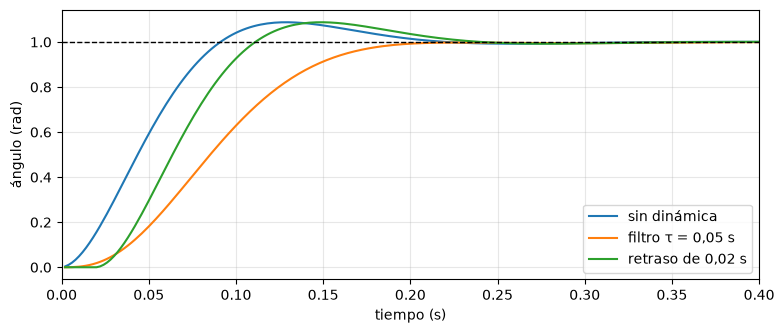

In [8]:
def escalon(extra: str, pasos: int = 500) -> tuple[np.ndarray, mujoco.MjModel]:
    m = mujoco.MjModel.from_xml_string(BRAZO.format(
        actuador=f'<position joint="j" kp="50" kv="2" {extra}/>'))
    d = mujoco.MjData(m)
    d.ctrl[0] = 1.0
    angulos = []
    for paso in range(pasos):
        mujoco.mj_step(m, d)
        angulos.append(d.qpos[0])
    return np.array(angulos), m

casos = {"sin dinámica": "",
         "filtro τ = 0,05 s": 'timeconst="0.05"',
         "retraso de 0,02 s": 'delay="0.02" nsample="10"'}

plt.figure(figsize=(9, 3.5))
t = np.arange(1, 501) * 0.002
for nombre, extra in casos.items():
    q, m = escalon(extra)
    arranca = (np.argmax(np.abs(q) > 1e-3) + 1) * 0.002
    llega = (np.argmax(q > 0.9) + 1) * 0.002
    print(f"{nombre:>18}: empieza a moverse a los {arranca:.3f} s, llega al 90 % a los {llega:.3f} s, "
          f"máximo {q.max():.3f} rad, activaciones (na) = {m.na}")
    plt.plot(t, q, label=nombre)
plt.axhline(1, color="k", ls="--", lw=1)
plt.xlabel("tiempo (s)")
plt.ylabel("ángulo (rad)")
plt.xlim(0, 0.4)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Tres comportamientos distintos con el **mismo** motor (kp = 50, kv = 2):

- **Sin dinámica**: se mueve desde el primer paso, llega al 90 % a los **0,078 s** y se pasa un poco (hasta 1,088 rad: un 9 % de sobreoscilación, porque kv = 2 es poca amortiguación para esta inercia, NB40).
- **Filtro de 0,05 s**: arranca suave, llega al 90 % casi el **doble** de tarde (0,148 s) y **ya no se pasa** (máximo 1,0). El filtro "redondea" el escalón: la orden que ve el motor sube poco a poco, y así no hay sacudida.
- **Retraso de 0,02 s**: la **misma** curva que sin dinámica, pero desplazada: no se mueve nada hasta los 0,022 s (los 0,02 de retraso más el primer paso), y llega al 90 % a los 0,098 = 0,078 + 0,02.

¿Y para qué complicarse? Porque una política entrenada en un simulador donde los motores responden **al instante** aprende a dar órdenes muy bruscas y a corregir muy deprisa. En el robot real, con 10-20 ms de retraso entre que decide y que el motor se mueve, esas correcciones llegan **tarde** y el robot vibra o se cae. Modelar el retraso (y aleatorizarlo, NB55) es uno de los trucos más importantes del *sim-to-real* (NB61).

(Los modelos más modernos de MuJoCo traen incluso un modelo de **motor eléctrico** completo, `dcmotor`, con resistencia, inductancia, saturación y calentamiento. Lo nombramos para que te suene; volveremos a los modelos de actuador en el NB61.)

### Límites: ctrlrange, forcerange

Los recordamos del NB42, porque son de lo más importante del modelo:

- **`ctrlrange`**: el rango de órdenes válidas. Si mandas algo fuera, MuJoCo lo **recorta** (con `ctrllimited`, que se activa solo al poner el rango).
- **`forcerange`**: la fuerza máxima que puede dar el motor. Es lo que separa un robot de verdad de uno con "superpoderes": sin él, un PD con kp alto daría pares de miles de N·m. Zancudo tiene ±150 N·m.


## 5 · Armature: la inercia del rotor

### Inercia reflejada

En el NB40 vimos que los motores de un robot giran **muy deprisa** con poca fuerza, y que una **reductora** (engranajes) convierte eso en giro lento con mucha fuerza. Si la reductora tiene una relación N (por ejemplo, 1:25: el rotor da 25 vueltas por cada vuelta de la articulación), entonces:

- el par en la articulación es N veces el del motor, y
- el rotor gira N veces más deprisa que la articulación.

Y aquí viene algo menos obvio. El rotor tiene su propia inercia J (pequeña: es un cilindro de pocos centímetros). Pero como gira N veces más deprisa, su energía cinética es ½·J·(N·q̇)² = ½·(**N²·J**)·q̇². Es decir: para la articulación, el rotor se comporta como una inercia **N² veces mayor**. A eso se le llama **inercia reflejada**, y en MuJoCo se escribe en el atributo **`armature`** de la articulación (se suma a la diagonal de la matriz de masas M, NB45).

Con números típicos: un rotor de J = 2·10⁻⁵ kg·m² con una reductora 1:25 refleja 625 · 2·10⁻⁵ = **0,0125 kg·m²**. Parece poco, pero compáralo con la inercia de un pie ligero que gira sobre el tobillo: con 0,1 kg y 10 cm, m·L²/3 ≈ **0,00033 kg·m²**. ¡El rotor "pesa" **38 veces** más que el pie! En las articulaciones distales (tobillos, muñecas, dedos), el `armature` **domina** la inercia.

### Por qué importa: estabilidad

Olvidarse del `armature` tiene dos consecuencias: el robot simulado es **más ágil** que el real (sus pies se mueven como si no tuvieran motor dentro), y la simulación es **menos estable**. Lo segundo lo entiendes ya con el NB49: la frecuencia ω = √(kp / inercia) y el ritmo de frenado kv / inercia **crecen** cuando la inercia es pequeña. Probémoslo con ese pie ligero de 0,1 kg, movido por un motor de posición con los valores de Zancudo (kp = 300, kv = 20):


In [9]:
PIE = '''
<mujoco>
  <compiler angle="radian"/>
  <option timestep="0.002" integrator="{integrador}"/>
  <worldbody>
    <body pos="0 0 1">
      <joint name="j" type="hinge" axis="0 1 0" armature="{armature}"/>
      <geom type="capsule" fromto="0 0 0  0.1 0 0" size="0.015" mass="0.1"/>
    </body>
  </worldbody>
  <actuator>
    <position joint="j" kp="300" kv="20"/>
  </actuator>
</mujoco>
'''

def mover_pie(integrador: str, armature: float) -> tuple[float, float, float]:
    m = mujoco.MjModel.from_xml_string(PIE.format(integrador=integrador, armature=armature))
    d = mujoco.MjData(m)
    d.ctrl[0] = 0.5
    angulos = []
    for paso in range(1000):
        mujoco.mj_step(m, d)
        angulos.append(d.qpos[0])
    angulos = np.array(angulos)
    mujoco.mj_forward(m, d)
    M = np.zeros((1, 1))
    mujoco.mj_fullM(m, d, M)
    llega = (np.argmax(angulos > 0.45) + 1) * 0.002
    return M[0, 0], np.abs(angulos).max(), llega

print(f"{'integrador':>12} {'armature':>9} | {'inercia total':>13} | {'pasito·kv/I':>11} | {'ángulo máx':>12} | llega al 90 %")
for integrador in ["Euler", "implicitfast"]:
    for armature in [0, 0.01, 0.02, 0.05]:
        inercia, maximo, llega = mover_pie(integrador, armature)
        print(f"{integrador:>12} {armature:>9} | {inercia:13.5f} | {0.002 * 20 / inercia:11.2f} | {maximo:12.2f} | {llega:.3f} s")

  integrador  armature | inercia total | pasito·kv/I |   ángulo máx | llega al 90 %
       Euler         0 |       0.00038 |      106.19 |     18370.44 | 0.002 s
       Euler      0.01 |       0.01038 |        3.85 |     13595.37 | 0.010 s
       Euler      0.02 |       0.02038 |        1.96 |         0.50 | 0.150 s
       Euler      0.05 |       0.05038 |        0.79 |         0.50 | 0.152 s
implicitfast         0 |       0.00038 |      106.19 |         0.50 | 0.152 s
implicitfast      0.01 |       0.01038 |        3.85 |         0.50 | 0.152 s
implicitfast      0.02 |       0.02038 |        1.96 |         0.50 | 0.150 s
implicitfast      0.05 |       0.05038 |        0.79 |         0.50 | 0.148 s


(Algunas filas de Euler habrán impreso el aviso de explosión del NB49.)

- **Con Euler**: sin `armature` (inercia 0,00038), el número pasito·kv/I vale 106, muy por encima de 2: **explota** (ángulos de miles de radianes). Con 0,01 aún vale 3,85: explota. Con **0,02** baja a 1,96, justo por debajo de 2... y ya va bien. La regla del NB49, otra vez, al milímetro.
- **Con implicitfast**: va bien en **todos** los casos, porque trata `kv` de forma implícita (NB49).
- **Y lo más interesante**: cuando funciona, el pie llega al 90 % en **0,15 s** con cualquier `armature`. ¿Cómo puede ser, si la inercia se multiplica por 50 o por 100? Porque el movimiento lo domina el amortiguamiento: con tanto kv, el pie se mueve como algo frenado en miel, a un ritmo kp/kv = 15 por segundo, que no depende de la inercia. El `armature` realista **estabiliza la simulación sin cambiar casi el comportamiento**.

Por eso Zancudo tiene `armature="0.01"` en todas sus articulaciones motorizadas desde el NB42 (y `0` en las de la raíz, que no tienen motor). Y por eso, en una entrevista, si te preguntan "¿qué parámetros del modelo revisarías primero para el *sim-to-real*?", el `armature` debe estar en tu lista (junto al rozamiento, las masas, el `damping`, los límites de fuerza y la latencia). Los valores reales salen de la hoja de datos del motor: J del rotor y relación N.


## 6 · Tendones

### Tendones fijos: un motor para varias articulaciones

Un **tendón** en MuJoCo es una "longitud" que se calcula a partir del robot, sobre la que pueden actuar motores, muelles o límites. Hay dos tipos.

El **tendón fijo** (`<fixed>`) es simplemente una **suma ponderada de ángulos**: longitud = c₁·q₁ + c₂·q₂ + ... Si un motor tira de ese tendón con una fuerza F, cada articulación recibe un par cᵢ·F. Así, **un solo motor mueve varias articulaciones**. Es lo que hacen muchas manos robóticas baratas: un único motor cierra los tres segmentos de un dedo.

Vamos a construir un dedo de dos falanges, cada una con un muelle (`stiffness`) que la devuelve a la posición recta, y un motor que tira de un tendón fijo con coeficientes 1 y 1:


In [10]:
DEDO = '''
<mujoco>
  <compiler angle="radian"/>
  <option gravity="0 0 0"/>
  <default>
    <joint type="hinge" axis="0 1 0" damping="0.05" range="0 1.6"/>
    <geom type="capsule" size="0.01" mass="0.02"/>
  </default>
  <worldbody>
    <body name="falange1" pos="0 0 0.5">
      <joint name="j1" stiffness="{k1}"/>
      <geom fromto="0 0 0  0.05 0 0"/>
      <body name="falange2" pos="0.05 0 0">
        <joint name="j2" stiffness="{k2}"/>
        <geom fromto="0 0 0  0.04 0 0"/>
      </body>
    </body>
  </worldbody>
  <tendon>
    <fixed name="flexor">
      <joint joint="j1" coef="1"/>
      <joint joint="j2" coef="1"/>
    </fixed>
  </tendon>
  <actuator>
    <motor name="tirar" tendon="flexor"/>
  </actuator>
</mujoco>
'''

for k1, k2 in [(0.1, 0.1), (0.1, 0.3)]:
    m = mujoco.MjModel.from_xml_string(DEDO.format(k1=k1, k2=k2))
    d = mujoco.MjData(m)
    d.ctrl[0] = 0.08                            # 0,08 N·m tirando del tendón
    for paso in range(3000):
        mujoco.mj_step(m, d)
    print(f"muelles {k1} y {k2}: ángulos {d.qpos.round(3)} rad, longitud del tendón {d.ten_length[0]:.3f}")

muelles 0.1 y 0.1: ángulos [0.8 0.8] rad, longitud del tendón 1.600
muelles 0.1 y 0.3: ángulos [0.8   0.267] rad, longitud del tendón 1.067


El motor da 0,08 N·m, y **cada** articulación recibe ese par (coeficiente 1). En equilibrio, cada muelle compensa el par: q = par / rigidez.

- Muelles iguales (0,1): las dos falanges se doblan **igual**, 0,08 / 0,1 = 0,8 rad. Longitud del tendón: 0,8 + 0,8 = 1,6.
- Segundo muelle 3 veces más duro (0,3): la segunda falange se dobla 3 veces **menos** (0,267). El reparto del movimiento lo deciden los muelles.

Es una forma elegante de **subactuación** (NB03): menos motores que articulaciones, y el resto lo decide la mecánica.

### Tendones espaciales: cables de verdad

El **tendón espacial** (`<spatial>`) es un cable de verdad: un camino que pasa por varios **sites** (y puede rodear formas como si fueran poleas), y su longitud es la longitud geométrica del camino. Se usa para músculos (en simulación biomecánica, como los modelos musculoesqueléticos de MyoSuite), cables de robots blandos, gomas elásticas (con `stiffness` y `springlength`)... No lo usaremos con Zancudo, pero ya sabes qué es si lo ves en un modelo.


## 7 · Restricciones de igualdad

### Obligar a que algo se cumpla

Una **restricción de igualdad** (`<equality>`) obliga al simulador a mantener una relación, resolviéndola con el mismo solucionador que los contactos (NB48: por eso es "blanda", con su `solref` y `solimp`). Las más usadas:

| Restricción | Qué obliga | Uso típico |
|---|---|---|
| `joint` | q₁ = polinomio(q₂) | acoplar articulaciones (dedos, mecanismos) |
| `connect` | dos cuerpos comparten un punto | cerrar **cadenas cerradas** (cuadriláteros articulados de rodillas, como Cassie) |
| `weld` | dos cuerpos mantienen su posición **y** orientación relativas | pegar objetos; "agarrar" un robot desde el mundo |
| `tendon` | longitud₁ = polinomio(longitud₂) | acoplar tendones |

Recuerda el NB42: el árbol de cuerpos de MuJoCo es eso, un **árbol** (cada cuerpo tiene una sola madre). Un mecanismo con un **lazo cerrado** (dos barras que salen de sitios distintos y se unen) no se puede escribir como árbol: se escribe como árbol abierto y se cierra con un `connect`.

### Acoplar dos articulaciones

Primero, `joint`: dos varillas en paralelo, un motor solo en la primera, y la restricción "q_b = −q_a" (el polinomio `polycoef="0 -1 0 0 0"` significa q_b = 0 − 1·q_a + 0·q_a² + ...):


In [11]:
ACOPLE = '''
<mujoco>
  <compiler angle="radian"/>
  <worldbody>
    <body pos="0 0 1">
      <joint name="a" type="hinge" axis="0 1 0" damping="0.5"/>
      <geom type="capsule" fromto="0 0 0  0.3 0 0" size="0.02" mass="1"/>
    </body>
    <body pos="0 0.3 1">
      <joint name="b" type="hinge" axis="0 1 0" damping="0.5"/>
      <geom type="capsule" fromto="0 0 0  0.3 0 0" size="0.02" mass="1"/>
    </body>
  </worldbody>
  <equality>
    <joint joint1="b" joint2="a" polycoef="0 -1 0 0 0"/>
  </equality>
  <actuator>
    <position joint="a" kp="40" kv="4"/>
  </actuator>
</mujoco>
'''
m = mujoco.MjModel.from_xml_string(ACOPLE)
d = mujoco.MjData(m)
d.ctrl[0] = 0.6
for paso in range(2000):
    mujoco.mj_step(m, d)
print("ángulos (a, b):", d.qpos.round(4))

ángulos (a, b): [ 0.6    -0.5984]


La varilla `b` **no tiene motor** y, aun así, está en −0,598: el espejo de `a`. No exactamente −0,6, porque la restricción es blanda (NB48) y la gravedad tira de `b`: el motor de `a` sostiene las dos a través de la restricción. Así se modela, por ejemplo, una pinza en la que un solo motor mueve los dos dedos en espejo.

### La "mano de dios": weld que se enciende y se apaga

Ahora el truco más útil para robots con patas. Cuando un robot real se enciende, no se le deja de pie sin más: se le **cuelga de una grúa** (un arnés), se activan los motores, se coloca en su postura, y **después** se baja. En simulación hacemos lo mismo con un `weld` entre el torso y el mundo, que se puede **apagar** a mitad de la simulación con `datos.eq_active`.

Usamos la postura `colgado` de la sección 3 (piernas agachadas con el torso a la altura normal, así que los pies quedan 10 cm en el aire). El `weld` lo sujeta durante 1 segundo, y después lo soltamos:


colgado, a los 0,5 s: 0.865 m;  a 1 s: 0.865 m
tras soltar: mínimo 0.747 m;  al final: 0.751 m;  giro del torso -0.040 rad


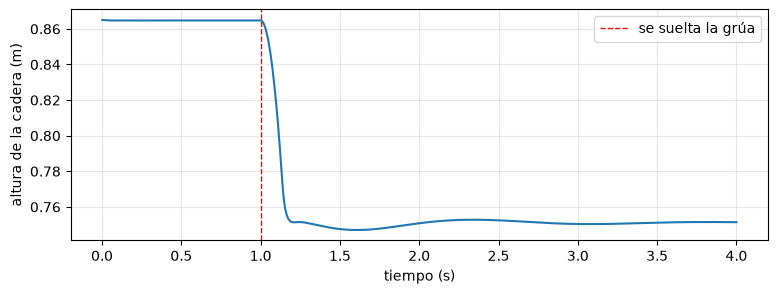

In [12]:
GRUA = '''
  <equality>
    <weld name="grua" body1="torso" active="false"/>
  </equality>
'''
m = mujoco.MjModel.from_xml_string(texto.replace("</mujoco>", KEYFRAMES + GRUA + "</mujoco>"))
d = mujoco.MjData(m)
mujoco.mj_resetDataKeyframe(m, d, m.key("colgado").id)
d.eq_active[m.equality("grua").id] = 1           # enganchamos la grúa

alturas = []
for paso in range(2000):                          # 4 segundos
    if paso == 500:                               # al segundo 1, soltamos
        d.eq_active[m.equality("grua").id] = 0
    mujoco.mj_step(m, d)
    alturas.append(0.865 + d.qpos[1])
alturas = np.array(alturas)

print(f"colgado, a los 0,5 s: {alturas[249]:.3f} m;  a 1 s: {alturas[499]:.3f} m")
print(f"tras soltar: mínimo {alturas[500:].min():.3f} m;  al final: {alturas[-1]:.3f} m;  giro del torso {d.qpos[2]:.3f} rad")

plt.figure(figsize=(9, 3))
plt.plot(np.arange(1, 2001) * 0.002, alturas)
plt.axvline(1.0, color="r", ls="--", lw=1, label="se suelta la grúa")
plt.xlabel("tiempo (s)")
plt.ylabel("altura de la cadera (m)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Durante el primer segundo, el torso se queda **clavado** a 0,865 m: la grúa lo sujeta mientras los motores llevan las piernas a su postura.
- Al soltar, cae los 10 cm, aterriza, se amortigua (mínimo 0,747 m) y se queda agachado a **0,751 m**, de pie. Es una **prueba de caída** (*drop test*), que se hace también con los robots reales.

Detalles:

- **`weld` con un solo cuerpo** (`body1="torso"`): lo pega **al mundo**, en la posición relativa que tenía en la postura de reposo del modelo (`qpos0`: el torso a 0,865 m). Por eso lo sujeta a esa altura.
- **`active="false"`**: empieza apagada. `datos.eq_active` es un array con un 0/1 por restricción, que se puede cambiar en cualquier momento. (`modelo.eq_active0` guarda el valor inicial.)
- **`m.equality("grua").id`**: el número de la restricción por su nombre, como con cuerpos y articulaciones.

Usos de la "mano de dios" en simulación: depurar un controlador de piernas sin que el robot se caiga (con el torso sujeto); los **currículos** de entrenamiento (NB55: al principio el robot está sujeto, y la ayuda se va quitando); y empezar episodios desde una postura en el aire.


## 8 · Sensores a fondo

### El catálogo

En el NB41 vimos los sensores de un robot real (IMU, encoders, sensores de fuerza) y en el NB42 pusimos a Zancudo un acelerómetro y un giróscopo. MuJoCo tiene muchísimos más. Los que más se usan en robots con patas:

| Sensor MJCF | Mide | Equivalente real |
|---|---|---|
| `jointpos`, `jointvel` | ángulo y velocidad de una articulación | encoder del motor |
| `actuatorfrc` | fuerza o par que da un actuador | corriente del motor × constante |
| `accelerometer`, `gyro` | aceleración lineal y velocidad angular en un site | IMU |
| `framequat`, `framepos` | orientación y posición de un objeto en el mundo | (solo con cámaras de captura de movimiento; en un robot real, se **estima**) |
| `velocimeter` | velocidad lineal en un site | (se estima) |
| `touch` | fuerza normal de los contactos dentro de un site | sensor de fuerza/presión en el pie |
| `force`, `torque` | fuerza/par de reacción en un site | sensor de 6 ejes del tobillo |
| `subtreecom` | centro de masas de un cuerpo y todo lo que cuelga de él | (se estima) |

Una advertencia muy importante: un sensor como `framequat` da la orientación **perfecta**, cosa que el robot real **no** tiene (la estima con la IMU, y se equivoca). Si entrenas una política que usa sensores "imposibles", no funcionará en el robot real. Lo profesional: la **política** solo ve lo que el robot real podría medir; los sensores perfectos se usan para la **recompensa** y el análisis (en el NB54 lo llamaremos "observación privilegiada").

### noise: un atributo que no hace nada

Los sensores tienen un atributo `noise` ("ruido"), y es muy tentador pensar que MuJoCo añade ruido a la medida. **No lo hace**: es solo una anotación para quien use el modelo. El ruido, si lo quieres, lo añades tú en tu código (en el entorno, NB55). Lo comprobaremos en la sección 12 al añadir sensores con `MjSpec`.

Los sensores se leen por nombre con `datos.sensor("nombre").data`, como ya sabes. Y su gran ventaja frente a calcular las cosas a mano: su lista **viaja con el modelo** (quien cargue el fichero sabe qué mide el robot), y salen ya ordenados en `datos.sensordata`, listos para ser la observación de una política.


## 9 · Mallas: formas de verdad

### Del CAD al simulador

Los robots reales se diseñan en programas de **CAD** (diseño asistido por ordenador), y sus piezas se exportan como **mallas**: superficies hechas de miles de triangulitos, en ficheros `.stl` o `.obj`. En MJCF, una malla se declara en `<asset>` y se usa en una forma con `type="mesh"`:

```xml
<compiler meshdir="mallas/"/>              <!-- carpeta donde buscar los ficheros -->
<asset>
  <mesh name="muslo" file="muslo.stl" scale="0.001 0.001 0.001"/>   <!-- de mm a m -->
</asset>
...
<geom type="mesh" mesh="muslo"/>
```

(Ojo con `scale`: muchos programas de CAD exportan en **milímetros**, y MuJoCo trabaja en metros.)

### La colisión usa la envolvente convexa

Aquí está la pregunta de entrevista: **MuJoCo choca las mallas usando su envolvente convexa**. La **envolvente convexa** de una forma es la forma convexa más pequeña que la contiene: imagina envolverla en papel de regalo muy tenso. Una forma es **convexa** si no tiene "entrantes": cualquier segmento entre dos de sus puntos queda dentro. Una esfera o una caja son convexas; una L, una taza o una mano, no.

¿Por qué? Porque detectar contactos entre formas convexas es **mucho** más rápido y fiable (hay algoritmos clásicos para ello, como GJK). El precio: los entrantes **desaparecen** para la física. Comprobémoslo con una malla en forma de L (que podemos escribir directamente con sus vértices, sin fichero) y una bola que cae justo encima del "escalón":


In [13]:
perfil = [(0, 0), (0.4, 0), (0.4, 0.1), (0.1, 0.1), (0.1, 0.4), (0, 0.4)]     # la L vista de lado (x, z)
vertices = [coordenada for y in (-0.2, 0.2) for x, z in perfil for coordenada in (x, y, z)]

ESCENA = '''
<mujoco>
  <compiler angle="radian"/>
  <asset>
    <mesh name="ele" vertex="{vertices}"/>
  </asset>
  <worldbody>
    <geom type="plane" size="2 2 0.1"/>
    {formas}
    <body name="bola" pos="0.3 0 1">
      <freejoint/>
      <geom type="sphere" size="0.03" mass="0.1"/>
    </body>
  </worldbody>
</mujoco>
'''
formas = {
    "malla en L": '<geom type="mesh" mesh="ele"/>',
    "dos cajas": '<geom type="box" pos="0.2 0 0.05" size="0.2 0.2 0.05"/>'
                 '<geom type="box" pos="0.05 0 0.25" size="0.05 0.2 0.15"/>',
}
for nombre, xml_formas in formas.items():
    m = mujoco.MjModel.from_xml_string(ESCENA.format(vertices=" ".join(map(str, vertices)), formas=xml_formas))
    d = mujoco.MjData(m)
    primer_contacto = None
    for paso in range(1500):
        mujoco.mj_step(m, d)
        if primer_contacto is None and d.ncon > 0:
            primer_contacto = d.qpos[2]
    print(f"{nombre:>10}: la bola toca a z = {primer_contacto:.3f} m y acaba en {d.qpos[:3].round(3)}")

malla en L: la bola toca a z = 0.228 m y acaba en [ 4.889 -0.     0.03 ]
 dos cajas: la bola toca a z = 0.116 m y acaba en [0.3  0.   0.13]


La L real tiene su escalón a 0,1 m de altura, así que la bola (de radio 0,03) debería posarse a 0,13 m y quedarse quieta allí.

- **Con la malla**: la bola toca **a unos 23 cm**, muy por encima del escalón: choca con la envolvente convexa, que es un **plano inclinado** que va de la punta de la torre al borde del escalón (el "papel de regalo"). Y como es una rampa, la bola **rueda** hacia abajo y acaba a varios metros.
- **Con dos cajas** (dos formas convexas que juntas hacen la L): la bola toca a ~12 cm (el contacto se detecta un pelín antes de tocar) y se queda en **(0,3, 0, 0,13)**, quieta en el escalón. Lo correcto.

(Sobre la línea de `vertices`: es una comprensión de lista con **tres** `for` encadenados, NB21, que se leen de izquierda a derecha como bucles anidados: para cada `y` (las dos caras de la L), para cada punto del perfil, para cada una de sus 3 coordenadas. Resultado: una lista plana de 36 números, que es lo que espera `vertex`. MuJoCo calcula solo la envolvente convexa.)

### La receta profesional

De aquí sale el patrón que verás en todos los modelos serios:

1. **Geometría visual**: la malla detallada del CAD, solo para dibujar (`contype="0" conaffinity="0"`, NB48: no choca). Suele ir en una clase `visual` y en el `group` 2.
2. **Geometría de colisión**: formas **sencillas** (cápsulas, cajas, esferas) o mallas convexas, que se parecen a la pieza lo suficiente. Clase `collision`, `group` 3, y no se dibujan.
3. Si una pieza cóncava **tiene** que chocar con detalle (una mano que agarra, una pieza con huecos), se **descompone** en varias piezas convexas con herramientas como **CoACD** o **V-HACD**, como hemos hecho a mano con las dos cajas.

Por qué no usar la malla del CAD para chocar: (1) la envolvente convexa no es la forma real; (2) una malla de miles de triángulos es mucho más **lenta** de chocar que una cápsula; (3) los pies de un robot con malla tienen muchos vértices y aristas que generan contactos "a saltos" (NB48). Para los pies, casi todos los modelos de bípedos usan cajas, cápsulas o unas pocas esferas.


## 10 · Python profesional: pathlib a fondo

### Rutas que no se rompen

En el NB26 conociste `pathlib.Path`: rutas que se unen con `/`, con `.name`, `.stem`, `.suffix`, `.parent`, `mkdir`, `exists`, `glob`... Un proyecto de simulación maneja **muchos** ficheros (modelos, mallas, políticas entrenadas, vídeos, resultados), así que vamos a completar la caja de herramientas.

El error más común con rutas es este: escribir `"robots/zancudo.xml"` funciona **solo** si el programa se ejecuta desde la carpeta `notebooks`, porque las rutas relativas se buscan desde el **directorio de trabajo** (NB26). Si otro script lo ejecuta desde otra carpeta, falla. La solución profesional es **anclar** las rutas a algo fijo:


In [14]:
from pathlib import Path

AQUI = Path.cwd().resolve()                     # la carpeta actual, como ruta ABSOLUTA
ROBOTS = AQUI / "robots"
print("ruta absoluta:     ", ROBOTS)
print("¿existe?           ", ROBOTS.exists(), "| ¿es carpeta?", ROBOTS.is_dir())
print("sus antepasados:   ", [p.name for p in ROBOTS.parents][:4])
print("relativa al curso: ", ROBOTS.relative_to(AQUI.parent))

ruta absoluta:      /home/gregori/dev/robotica/notebooks/robots
¿existe?            True | ¿es carpeta? True
sus antepasados:    ['notebooks', 'robotica', 'dev', 'gregori']
relativa al curso:  notebooks/robots


- **`.resolve()`** convierte una ruta en **absoluta** (desde la raíz del disco, `/`), resolviendo `..` y atajos. Una ruta absoluta funciona desde cualquier sitio.
- **`.parents`** es la secuencia de carpetas que la contienen, de la más cercana a la más lejana (`.parent` es solo la primera).
- **`.relative_to(otra)`** hace lo contrario: expresa una ruta **respecto** a otra (útil para mostrar rutas cortas o para guardarlas en un informe sin depender del ordenador).

En un fichero `.py` (no en un notebook), el ancla perfecta es **`Path(__file__).resolve().parent`**: la carpeta donde está **el propio fichero**, venga de donde venga quien lo ejecuta. `__file__` es una variable que Python pone en cada módulo con su ruta (en los notebooks no existe, por eso aquí usamos `cwd`). Así lo hace, por ejemplo, el `zancudo_env.py` de una buena librería.

### Más herramientas


In [15]:
modelo = ROBOTS / "zancudo.xml"
print("con otra extensión: ", modelo.with_suffix(".urdf").name)
print("con otro nombre:    ", modelo.with_name("zancudo_v2.xml").name)
print("tamaño:             ", modelo.stat().st_size, "bytes")
print("todos los .xml (en subcarpetas también):", sorted(p.name for p in AQUI.rglob("*.xml"))[:6])

con otra extensión:  zancudo.urdf
con otro nombre:     zancudo_v2.xml
tamaño:              3365 bytes
todos los .xml (en subcarpetas también): ['zancudo.xml', 'zancudo_v2.xml']


- **`.with_suffix(...)`** y **`.with_name(...)`** dan una ruta **nueva** cambiando la extensión o el nombre (no tocan ningún fichero: un `Path` es solo una dirección, NB26). Perfecto para "guarda el resultado al lado, con otro nombre".
- **`.stat()`** da información del fichero: tamaño (`st_size`), fecha de modificación (`st_mtime`)...
- **`.rglob("*.xml")`** busca **recursivamente** (en todas las subcarpetas); `.glob` busca solo en la carpeta. Devuelven un **generador** (NB48 y P4), por eso lo pasamos por `sorted`.

### Carpetas temporales

Para pruebas que escriben ficheros (como las de la sección 12), lo limpio es usar una carpeta **temporal**, que se borra sola al terminar. El módulo `tempfile` la da como **gestor de contexto** (P4 y NB49):


In [16]:
import tempfile

with tempfile.TemporaryDirectory() as carpeta:
    prueba = Path(carpeta) / "prueba.xml"
    prueba.write_text(modelo.read_text())
    print("escrito:", prueba.name, "| ¿existe dentro?", prueba.exists())
print("¿existe después del with?", prueba.exists())

escrito: prueba.xml | ¿existe dentro? True
¿existe después del with? False


Al salir del `with`, la carpeta y todo lo que tenía dentro **desaparecen** (el `__exit__` las borra, aunque haya habido un error). Los tests de `pytest` (NB46) tienen lo mismo ya hecho: el *fixture* `tmp_path`.

(Para borrar a mano: `ruta.unlink()` borra un fichero, `ruta.unlink(missing_ok=True)` no protesta si no existe, y `carpeta.rmdir()` borra una carpeta **vacía**. Y `mkdir(parents=True, exist_ok=True)` crea una carpeta con todas las que falten por encima, sin protestar si ya existe: la forma segura de "asegúrate de que esta carpeta exista".)


## 11 · Python profesional: xml.etree

### Leer un XML como un árbol

Un fichero MJCF es XML (NB42): etiquetas dentro de etiquetas, es decir, un **árbol**. La biblioteca estándar de Python trae un módulo para leer, recorrer, modificar y escribir XML: **`xml.etree.ElementTree`**. Es una herramienta general (sirve para cualquier XML: URDF, SVG, configuraciones...), y conviene conocerla.


In [17]:
import xml.etree.ElementTree as ET

arbol = ET.parse(modelo)                         # lee y analiza el fichero
raiz = arbol.getroot()                           # el elemento <mujoco>
print("raíz:", raiz.tag, raiz.attrib)
print("secciones:", [hijo.tag for hijo in raiz])

raíz: mujoco {'model': 'zancudo'}
secciones: ['compiler', 'option', 'default', 'visual', 'asset', 'worldbody', 'actuator', 'sensor']


Cada **elemento** (cada etiqueta) es un objeto con:

- **`.tag`**: el nombre de la etiqueta (`"mujoco"`, `"body"`...).
- **`.attrib`**: un **diccionario** con sus atributos (`{"model": "zancudo"}`). Todos los valores son **textos**, nunca números: `"0.865"`, no 0.865.
- Sus **hijos**: un elemento se recorre como una lista (`for hijo in raiz`).

Y tres formas de buscar:


In [18]:
print("todas las articulaciones (recorriendo todo el árbol con iter):")
for articulacion in raiz.iter("joint"):
    print("   ", articulacion.get("name"), "| rango:", articulacion.get("range"))

print("\nla forma del pie derecho (con find y una ruta):")
print("   ", raiz.find(".//body[@name='pie_d']/geom").attrib)

print("\nnúmero de cuerpos (findall):", len(raiz.findall(".//body")))

todas las articulaciones (recorriendo todo el árbol con iter):
    None | rango: None
    raiz_x | rango: None
    raiz_z | rango: None
    raiz_giro | rango: None
    cadera_d | rango: -1.57 1.57
    rodilla_d | rango: -2.6 0
    tobillo_d | rango: -0.78 0.78
    cadera_i | rango: -1.57 1.57
    rodilla_i | rango: -2.6 0
    tobillo_i | rango: -0.78 0.78

la forma del pie derecho (con find y una ruta):
    {'name': 'pie_d', 'type': 'capsule', 'fromto': '-0.06 0 -0.03  0.14 0 -0.03', 'size': '0.03', 'mass': '0.8', 'rgba': '0.85 0.55 0.25 1'}

número de cuerpos (findall): 7


- **`.iter("joint")`** recorre **todo** el árbol (hijos, nietos...) y da cada elemento con esa etiqueta.
- **`.find(ruta)`** da el **primero** que encaja con una ruta; **`.findall(ruta)`**, todos. Las rutas son un mini-lenguaje (un trozo de **XPath**): `.//body` = "cualquier `body` a cualquier profundidad"; `[@name='pie_d']` = "cuyo atributo `name` sea `pie_d`"; `/geom` = "su hijo `geom`".
- **`.get("name")`** lee un atributo, y da `None` si no existe (como el `get` de los diccionarios, NB21).

¿Ves la **primera** articulación de la lista, con nombre `None` y sin rango? No es una articulación: es el `<joint>` del `<default>`. Para `xml.etree` es una etiqueta `joint` más; no sabe nada de MuJoCo. Primera señal de sus límites.

### Modificar y guardar

Hagamos un "Zancudo blando": motores con la mitad de kp. En el fichero, kp está en el `<default>`:


In [19]:
posicion_por_defecto = raiz.find("default/position")
print("antes:  ", posicion_por_defecto.attrib)
posicion_por_defecto.set("kp", str(float(posicion_por_defecto.get("kp")) / 2))
print("después:", posicion_por_defecto.attrib)

with tempfile.TemporaryDirectory() as carpeta:
    ruta_blando = Path(carpeta) / "zancudo_blando.xml"
    arbol.write(ruta_blando, encoding="unicode")
    blando = mujoco.MjModel.from_xml_path(str(ruta_blando))
print("kp de los motores del modelo blando:", blando.actuator_gainprm[:, 0])

antes:   {'kp': '300', 'kv': '20', 'forcelimited': 'true', 'forcerange': '-150 150'}
después: {'kp': '150.0', 'kv': '20', 'forcelimited': 'true', 'forcerange': '-150 150'}
kp de los motores del modelo blando: [150. 150. 150. 150. 150. 150.]


Funciona: `.set(atributo, texto)` cambia un atributo (¡como texto: de ahí el `str(float(...) / 2)`!), y `arbol.write(...)` guarda el árbol en un fichero.

### Por qué no basta

`xml.etree` trata el MJCF como **texto con forma de árbol**, sin entender nada de MuJoCo. Por eso:

- **No sabe de valores por defecto**: si preguntas por el kp del motor `m_rodilla_d`, su elemento **no tiene** atributo `kp` (lo hereda del default). Para saber el valor real tendrías que reimplementar las reglas de herencia de MuJoCo. Lo mismo con las unidades (¿grados o radianes?), las posiciones relativas, las inercias que se calculan solas...
- **No comprueba nada**: puedes escribir `kp="hola"` o un cuerpo sin forma, y no te enterarás hasta cargarlo.
- **Todo son textos**: hay que convertir números y vectores a mano, en los dos sentidos.

Es la herramienta adecuada para cosas **genéricas** (renombrar etiquetas, convertir formatos, leer un URDF). Para modificar modelos de MuJoCo hay algo mucho mejor.


## 12 · MjSpec: modelos desde Python

### El modelo antes de compilar

Recuerda el NB45: MuJoCo **compila** el fichero MJCF a un `MjModel`, una estructura de arrays optimizada para simular rápido. Pero el `MjModel` es incómodo de modificar: puedes cambiar valores (`m.opt.timestep`, `m.geom_friction`...), pero **no** añadir ni quitar piezas (los arrays tienen tamaño fijo).

**`MjSpec`** ("especificación") es el paso **intermedio**: el modelo tal como está escrito, con su árbol de cuerpos, sus clases y sus nombres, pero como **objetos de Python** en vez de texto. Se puede leer de un fichero, modificar, ampliar, y compilar cuando se quiera:

```
   fichero MJCF  ──from_file──►  MjSpec  ──compile()──►  MjModel  ──►  simular
                 ◄──to_xml()───  (editable)               (rápido, fijo)
```

Es la forma **moderna** (desde MuJoCo 3.2) y recomendada de fabricar modelos desde Python. Entiende todo lo que hemos visto hoy: clases, unidades, herencia... porque es el propio compilador de MuJoCo.


In [20]:
spec = mujoco.MjSpec.from_file(str(modelo))
print("nombre:", spec.modelname)
print("cuerpos:", [cuerpo.name for cuerpo in spec.bodies])
print("integrador:", mujoco.mjtIntegrator(spec.option.integrator).name, "| pasito:", spec.option.timestep)
print("el pie derecho:", spec.body("pie_d").pos, "| sus formas:", [g.name for g in spec.body("pie_d").geoms])

nombre: zancudo
cuerpos: ['world', 'torso', 'muslo_d', 'pierna_d', 'pie_d', 'muslo_i', 'pierna_i', 'pie_i']
integrador: mjINT_EULER | pasito: 0.002
el pie derecho: [ 0.   0.  -0.4] | sus formas: ['pie_d']


Cada pieza es un objeto con atributos que se llaman **igual** que en el MJCF: `spec.body("pie_d").pos`, `spec.option.timestep`, `spec.geom("pie_d").friction`... Y se buscan por nombre con `spec.body(...)`, `spec.joint(...)`, `spec.actuator(...)`, como en el `MjModel`.

### Añadir sensores, posturas y opciones

Ahora, la forma profesional de lo que en la sección 3 hicimos reemplazando texto. Vamos a:

1. Poner el integrador `implicitfast` (la conclusión del NB49).
2. Añadir a cada pie un **site** en forma de caja que envuelva la planta, y un sensor **`touch`** que mida la fuerza de los contactos dentro de esa caja.
3. Añadir un sensor de orientación (`framequat`) con un `noise` de 0,01 (para comprobar que no hace nada), el centro de masas (`subtreecom`) y el par del motor de la rodilla (`actuatorfrc`).
4. Añadir la postura `agachado`.


In [21]:
spec.option.integrator = mujoco.mjtIntegrator.mjINT_IMPLICITFAST

for lado in ["d", "i"]:
    spec.body(f"pie_{lado}").add_site(name=f"planta_{lado}", type=mujoco.mjtGeom.mjGEOM_BOX,
                                      size=[0.11, 0.04, 0.035], pos=[0.04, 0, -0.03])
    spec.add_sensor(name=f"tacto_{lado}", type=mujoco.mjtSensor.mjSENS_TOUCH,
                    objtype=mujoco.mjtObj.mjOBJ_SITE, objname=f"planta_{lado}")

spec.add_sensor(name="orientacion", type=mujoco.mjtSensor.mjSENS_FRAMEQUAT,
                objtype=mujoco.mjtObj.mjOBJ_SITE, objname="imu", noise=0.01)
spec.add_sensor(name="cdm", type=mujoco.mjtSensor.mjSENS_SUBTREECOM,
                objtype=mujoco.mjtObj.mjOBJ_BODY, objname="torso")
spec.add_sensor(name="par_rodilla_d", type=mujoco.mjtSensor.mjSENS_ACTUATORFRC,
                objtype=mujoco.mjtObj.mjOBJ_ACTUATOR, objname="m_rodilla_d")

spec.add_key(name="agachado", qpos=[0, -baja, 0, a, -2 * a, a, a, -2 * a, a],
             ctrl=[a, -2 * a, a, a, -2 * a, a])

m = spec.compile()
print("sensores:", [m.sensor(i).name for i in range(m.nsensor)])
print("posturas:", [m.key(i).name for i in range(m.nkey)], "| integrador:", mujoco.mjtIntegrator(m.opt.integrator).name)

sensores: ['acelerometro', 'giroscopo', 'tacto_d', 'tacto_i', 'orientacion', 'cdm', 'par_rodilla_d']
posturas: ['agachado'] | integrador: mjINT_IMPLICITFAST


El patrón es siempre el mismo: **`add_...`** en el sitio donde va la pieza. Los sites y formas se añaden a un **cuerpo** (`cuerpo.add_site`, `cuerpo.add_geom`, `cuerpo.add_body`, `cuerpo.add_joint`); los sensores, actuadores, posturas y tendones, al **spec** (`spec.add_sensor`, `spec.add_actuator`, `spec.add_key`...). Los argumentos se llaman como los atributos del MJCF, y los tipos se dan con las enumeraciones de MuJoCo (`mjtGeom`, `mjtSensor`, `mjtObj`: NB48, son `IntEnum`, que conoces del P3).

El site `planta_d` es una caja de 22 × 8 × 7 cm (`size` da las **mitades**) que envuelve la cápsula del pie; el sensor `touch` suma la fuerza normal de todos los contactos cuyo punto cae dentro. Probémoslo todo:


In [22]:
d = mujoco.MjData(m)
mujoco.mj_resetDataKeyframe(m, d, m.key("agachado").id)
for paso in range(1000):
    mujoco.mj_step(m, d)

for nombre in ["tacto_d", "tacto_i", "orientacion", "cdm", "par_rodilla_d"]:
    print(f"{nombre:>14}: {d.sensor(nombre).data.round(3)}")
print(f"\nsuma de los dos tactos: {d.sensor('tacto_d').data[0] + d.sensor('tacto_i').data[0]:.1f} N;  "
      f"peso: {m.body_subtreemass[0] * 9.81:.1f} N")

mujoco.mj_forward(m, d)                          # recalcula los sensores en el estado actual...
lectura1 = d.sensor("orientacion").data.copy()
mujoco.mj_forward(m, d)                          # ...y otra vez, en el MISMO estado
print("¿el 'noise' ha cambiado la lectura al recalcular?", not np.array_equal(lectura1, d.sensor("orientacion").data))

       tacto_d: [115.778]


       tacto_i: [115.778]
   orientacion: [ 1.     0.    -0.023  0.   ]
           cdm: [0.031 0.    0.698]
 par_rodilla_d: [16.046]

suma de los dos tactos: 231.6 N;  peso: 231.5 N
¿el 'noise' ha cambiado la lectura al recalcular? False


- **Tacto**: 115,8 N en cada pie; suman **231,6 N = el peso** de Zancudo (23,6 kg × 9,81). Es la medida del NB48 (fuerza total = peso), ahora con un sensor que viaja con el modelo.
- **Orientación**: el cuaternión (NB46) `[1, 0, −0,023, 0]`: casi la identidad, con un pequeño giro de 2,6° (2 × 0,023 rad) alrededor del eje y. Zancudo está ligeramente inclinado.
- **Centro de masas**: 3 cm por delante del tobillo y a 0,70 m de altura (agachado).
- **Par de la rodilla**: 16 N·m, lo que hace falta para sostener el peso con la rodilla doblada.
- **noise**: recalcular dos veces con el **mismo** estado da **exactamente** la misma lectura. Confirmado: MuJoCo no añade ruido. (¿Por qué llamamos a `mj_forward` antes de la primera lectura? Porque los sensores que deja `mj_step` se calcularon al **principio** del paso, antes de avanzar el estado, NB45. Si comparáramos esa lectura con una recalculada, saldrían distintas... pero por el paso de tiempo, no por ruido.)

### Ver el XML

Un `MjSpec` se puede volver a convertir en texto MJCF con `to_xml()`:


In [23]:
xml = spec.to_xml()
inicio = xml.find("<default>")
print(xml[inicio:inicio + 420])

<default>
    <joint armature="0.01" damping="1" axis="0 -1 0"/>
    <geom rgba="0.85 0.55 0.25 1"/>
    <general forcelimited="true" forcerange="-150 150" biastype="affine" gainprm="300" biasprm="0 -300 -20"/>
  </default>

  <asset>
    <texture type="skybox" colorspace="auto" builtin="gradient" rgb1="0.5 0.6 0.7" rgb2="0.1 0.1 0.15" width="200" height="1200"/>
    <texture type="2d" colorspace="auto" name="cuadros


Mira la clase por defecto de los motores: donde nuestro fichero decía `<position kp="300" kv="20" .../>`, el XML generado dice `<general ... biastype="affine" gainprm="300" biasprm="0 -300 -20"/>`. ¡La sección 4 confirmada por el propio MuJoCo: un `position` **es** un `general`! (`to_xml` escribe la forma "larga", la de verdad, porque el atajo ya se ha traducido al leer el fichero.)

### Pegar modelos: attach

Una función muy potente: **`attach`**, que pega un modelo **entero** dentro de otro. Así se monta una escena con varios robots, un robot con una herramienta, o un robot con una carga. Pongámosle a Zancudo una **mochila**: una caja de 5 kg, definida como un modelo aparte, pegada a un site en la espalda del torso. El `prefix` añade un prefijo a todos los nombres del modelo pegado, para que no choquen con los de Zancudo:


In [24]:
MOCHILA = '''
<mujoco>
  <worldbody>
    <body name="caja">
      <geom type="box" size="0.05 0.12 0.15" mass="{masa}" rgba="0.2 0.5 0.3 1"/>
    </body>
  </worldbody>
</mujoco>
'''

def con_mochila(x: float, masa: float, kp: float = 300) -> tuple[float, float | None]:
    zancudo_spec = mujoco.MjSpec.from_file(str(modelo))
    enganche = zancudo_spec.body("torso").add_site(name="enganche", pos=[x, 0, 0.3])
    zancudo_spec.attach(mujoco.MjSpec.from_string(MOCHILA.format(masa=masa)), prefix="mochila_", site=enganche)
    m = zancudo_spec.compile()
    m.actuator_gainprm[:, 0] = kp                    # kp de todos los motores...
    m.actuator_biasprm[:, 1] = -kp                   # ...en los dos sitios donde aparece (sección 4)
    d = mujoco.MjData(m)
    mujoco.mj_forward(m, d)
    cdm_x = d.subtree_com[m.body("torso").id][0]
    for paso in range(int(round(10 / m.opt.timestep))):      # 10 segundos
        mujoco.mj_step(m, d)
        if abs(d.qpos[2]) > 0.3:                             # el torso se ha inclinado más de 17°
            return cdm_x, d.time
    return cdm_x, None

for x, masa, kp in [(0.15, 5, 300), (-0.05, 2, 300), (-0.1, 5, 300), (-0.1, 5, 600)]:
    cdm_x, cae = con_mochila(x, masa, kp)
    resultado = f"se CAE a los {cae:.2f} s" if cae else "aguanta 10 s"
    print(f"mochila de {masa} kg en x = {x:+.2f} m, kp = {kp}: CdM en x = {cdm_x:+.3f} m → {resultado}")

mochila de 5 kg en x = +0.15 m, kp = 300: CdM en x = +0.028 m → aguanta 10 s


mochila de 2 kg en x = -0.05 m, kp = 300: CdM en x = -0.001 m → aguanta 10 s
mochila de 5 kg en x = -0.10 m, kp = 300: CdM en x = -0.015 m → se CAE a los 2.11 s


mochila de 5 kg en x = -0.10 m, kp = 600: CdM en x = -0.015 m → aguanta 10 s


Un resultado curioso, y muy instructivo:

- 5 kg **delante** (CdM desplazado 2,8 cm hacia delante): aguanta.
- 2 kg detrás, cerca de la espalda: aguanta.
- 5 kg **detrás**, a 10 cm (CdM solo **1,5 cm** hacia atrás): **se cae** de espaldas, poco a poco, a los 2,1 segundos.
- La misma mochila con motores el doble de duros (kp = 600): **aguanta**.

¿Por qué se cae con el CdM a 1,5 cm del tobillo, si el talón llega 9 cm por detrás? Dos razones, que ya conoces:

1. **Los motores son muelles** (NB40). Con el peso detrás, las articulaciones **ceden** un poco hacia atrás; eso lleva el CdM más atrás; eso aumenta el par que tira hacia atrás; y las articulaciones ceden más... Es una **realimentación** que crece si los muelles no son lo bastante duros frente al par de la gravedad (por eso con kp = 600 no pasa). Zancudo con `ctrl = 0` no **controla** su equilibrio: solo intenta mantener los ángulos, y eso no basta.
2. **El talón es corto** (9 cm por detrás del tobillo, frente a 17 cm de puntera, NB42). Hacia atrás hay mucho menos margen que hacia delante.

Es exactamente el problema que resolverá el **control de equilibrio** del Bloque B (NB51-NB52): mover las articulaciones para mantener el centro de presiones dentro del pie (NB39), en vez de quedarse rígido.

(Sobre el código: `attach` devuelve el marco donde ha pegado el modelo; `site=enganche` dice dónde. Y `m.actuator_gainprm[:, 0] = kp` modifica el **modelo compilado** directamente, como en el NB49: para cambiar un número, no hace falta recompilar.)

### Quitar piezas y recompilar sin perder el estado

Dos funciones más para terminar:

- **`spec.delete(pieza)`** quita una pieza (y, si es un cuerpo, todo lo que cuelga de él).
- **`spec.recompile(modelo, datos)`** compila de nuevo **conservando** el estado de la simulación: posiciones, velocidades, tiempo. Permite cambiar el modelo **a mitad** de una simulación (añadir un obstáculo, quitar una pieza...).


In [25]:
spec2 = mujoco.MjSpec.from_file(str(modelo))
m = spec2.compile()
d = mujoco.MjData(m)
for paso in range(500):
    mujoco.mj_step(m, d)
print(f"antes:   tiempo {d.time:.3f} s, {m.nsite} site(s), qpos[:3] = {d.qpos[:3].round(4)}")

spec2.body("torso").add_site(name="cabeza", pos=[0, 0, 0.5])
spec2.delete(spec2.sensor("giroscopo"))
m, d = spec2.recompile(m, d)
print(f"después: tiempo {d.time:.3f} s, {m.nsite} site(s), qpos[:3] = {d.qpos[:3].round(4)}, sensores {[m.sensor(i).name for i in range(m.nsensor)]}")

antes:   tiempo 1.000 s, 1 site(s), qpos[:3] = [-0.0021 -0.0055 -0.003 ]
después: tiempo 1.000 s, 2 site(s), qpos[:3] = [-0.0021 -0.0055 -0.003 ], sensores ['acelerometro']


El tiempo y las posiciones siguen exactamente donde estaban, y el modelo tiene un site más y un sensor menos. `recompile` devuelve un `MjModel` y un `MjData` **nuevos** (por eso hay que guardarlos: `m, d = ...`).


## 13 · Python profesional: el patrón constructor

### Fabricar robots con parámetros

En el NB42 fabricamos las piernas de Zancudo con una función y f-strings. Con `MjSpec` podemos ir mucho más lejos: fabricar el robot **entero** desde Python, con sus medidas como **parámetros**. ¿Para qué? Para una de las técnicas más usadas en robótica moderna: entrenar con **muchas variantes** del robot (piernas un poco más largas o más cortas, más o menos masa...), para que la política funcione aunque el robot real no sea exactamente como el modelo (la **aleatorización**, NB55), o para **diseñar** el robot buscando las mejores medidas.

Cuando un objeto tiene **muchas** opciones (la mayoría con un valor razonable por defecto), una función con 15 argumentos se vuelve ilegible. El patrón de diseño **constructor** (*builder*) lo resuelve: un objeto que se va **configurando paso a paso**, con un método para cada aspecto, y al final un método `construir()` que fabrica el resultado. Y un truco para que se lea como una frase: que cada método de configuración **devuelva el propio constructor** (`return self`), para poder **encadenar** llamadas:

```python
modelo = ConstructorBipedo().piernas(0.5, 0.5).torso(15).motores(kp=400, kv=25).construir()
```

A esto se le llama **interfaz fluida** (*fluent interface*); ya te la presentó el P5 (apartado 6) al hablar de `Self`. Lo verás en muchas bibliotecas (en pandas, `df.dropna().sort_values(...).head()`; las propias `MjSpec` usan algo parecido).


In [26]:
from typing import Self

class ConstructorBipedo:
    # Fabrica bípedos planos como Zancudo, con medidas configurables.

    def __init__(self, nombre: str = "bipedo"):
        self.nombre = nombre
        self.largo_muslo, self.largo_pierna = 0.4, 0.4
        self.masa_torso = 12.0
        self.kp, self.kv = 300.0, 20.0

    def piernas(self, muslo: float, pierna: float) -> Self:
        self.largo_muslo, self.largo_pierna = muslo, pierna
        return self

    def torso(self, masa: float) -> Self:
        self.masa_torso = masa
        return self

    def motores(self, kp: float, kv: float) -> Self:
        self.kp, self.kv = kp, kv
        return self

    def construir(self) -> mujoco.MjModel:
        spec = mujoco.MjSpec()
        spec.modelname = self.nombre
        spec.compiler.degree = False                       # ¡radianes! (sección 2)
        spec.option.integrator = mujoco.mjtIntegrator.mjINT_IMPLICITFAST
        self._valores_por_defecto(spec)
        spec.worldbody.add_geom(name="suelo", type=mujoco.mjtGeom.mjGEOM_PLANE, size=[20, 20, 0.1])
        torso = self._torso(spec)
        for lado, y in [("d", -0.1), ("i", 0.1)]:
            self._pierna(spec, torso, lado, y)
        return spec.compile()

    def _valores_por_defecto(self, spec: mujoco.MjSpec) -> None:
        spec.default.joint.axis = [0, -1, 0]
        spec.default.joint.damping = [1, 0, 0]
        spec.default.joint.armature = 0.01
        spec.default.geom.friction = [1, 0.005, 0.0001]

    def _torso(self, spec: mujoco.MjSpec) -> mujoco.MjsBody:
        altura = self.largo_muslo + self.largo_pierna + 0.065
        torso = spec.worldbody.add_body(name="torso", pos=[0, 0, altura])
        for nombre, tipo, eje in [("raiz_x", mujoco.mjtJoint.mjJNT_SLIDE, [1, 0, 0]),
                                  ("raiz_z", mujoco.mjtJoint.mjJNT_SLIDE, [0, 0, 1]),
                                  ("raiz_giro", mujoco.mjtJoint.mjJNT_HINGE, [0, 1, 0])]:
            torso.add_joint(name=nombre, type=tipo, axis=eje, damping=[0, 0, 0], armature=0)
        torso.add_geom(name="torso", type=mujoco.mjtGeom.mjGEOM_CAPSULE,
                       fromto=[0, 0, 0.05, 0, 0, 0.45], size=[0.08, 0, 0], mass=self.masa_torso)
        return torso

    def _pierna(self, spec: mujoco.MjSpec, torso: mujoco.MjsBody, lado: str, y: float) -> None:
        capsula = mujoco.mjtGeom.mjGEOM_CAPSULE
        muslo = torso.add_body(name=f"muslo_{lado}", pos=[0, y, 0])
        muslo.add_joint(name=f"cadera_{lado}", range=[-1.57, 1.57])
        muslo.add_geom(type=capsula, fromto=[0, 0, 0, 0, 0, -self.largo_muslo], size=[0.05, 0, 0], mass=3)
        pierna = muslo.add_body(name=f"pierna_{lado}", pos=[0, 0, -self.largo_muslo])
        pierna.add_joint(name=f"rodilla_{lado}", range=[-2.6, 0])
        pierna.add_geom(type=capsula, fromto=[0, 0, 0, 0, 0, -self.largo_pierna], size=[0.04, 0, 0], mass=2)
        pie = pierna.add_body(name=f"pie_{lado}", pos=[0, 0, -self.largo_pierna])
        pie.add_joint(name=f"tobillo_{lado}", range=[-0.78, 0.78])
        pie.add_geom(name=f"pie_{lado}", type=capsula, fromto=[-0.06, 0, -0.03, 0.14, 0, -0.03],
                     size=[0.03, 0, 0], mass=0.8)
        for articulacion, rango in [("cadera", [-1.57, 1.57]), ("rodilla", [-2.6, 0]), ("tobillo", [-0.78, 0.78])]:
            motor = spec.add_actuator(name=f"m_{articulacion}_{lado}", target=f"{articulacion}_{lado}",
                                      trntype=mujoco.mjtTrn.mjTRN_JOINT, ctrlrange=rango, forcerange=[-150, 150])
            motor.set_to_position(kp=self.kp, kv=self.kv)

Lo importante del diseño:

- **Los métodos públicos** (`piernas`, `torso`, `motores`) solo **guardan** opciones y devuelven `self`. No fabrican nada todavía: así el orden en que se llamen da igual.
- **`construir()`** es el único que fabrica. Y lo hace **delegando** en métodos privados (con `_` delante, NB24: "uso interno") que hacen una cosa cada uno. Una función de 60 líneas se convierte en cuatro de 10-15, cada una con un nombre que explica qué hace.
- **`-> Self`** (de `typing`, desde Python 3.11; repaso del P5, apartado 6): la anotación de "devuelve un objeto de esta misma clase". Si alguien crea una subclase (`class ConstructorHumanoide(ConstructorBipedo)`), el editor sabrá que `.piernas(...)` devuelve un `ConstructorHumanoide`, no un `ConstructorBipedo`.
- **`motor.set_to_position(kp=..., kv=...)`**: el atajo `position` en versión `MjSpec`. Rellena `gainprm`, `biasprm` y `biastype` como en la sección 4 (hay también `set_to_motor`, `set_to_velocity`...).
- Fíjate en el `damping=[1, 0, 0]`: en esta versión de MuJoCo, la amortiguación de una articulación es un **vector** de 3 números (admite amortiguación que crece con la velocidad), y el primero es el `damping` de siempre. Si pones un número suelto, `MjSpec` protesta.

¿Fabrica a Zancudo de verdad? Comparemos con el fichero:


In [27]:
fabricado = ConstructorBipedo("zancudo").construir()
print(f"{'':>12} | {'nq':>3} | {'nu':>3} | {'masa':>5} | kp/kv del primer motor")
for nombre, m in [("fichero", zancudo), ("constructor", fabricado)]:
    print(f"{nombre:>12} | {m.nq:3d} | {m.nu:3d} | {m.body_subtreemass[0]:5.1f} | "
          f"{m.actuator_gainprm[0, 0]:.0f} / {-m.actuator_biasprm[0, 2]:.0f}")

             |  nq |  nu |  masa | kp/kv del primer motor
     fichero |   9 |   6 |  23.6 | 300 / 20
 constructor |   9 |   6 |  23.6 | 300 / 20


Mismas coordenadas, mismos motores, misma masa, mismos kp y kv. (La única diferencia buscada: el fabricado usa `implicitfast`.)

### Un barrido de morfologías

Ahora la recompensa. ¿Cómo cambia la **robustez** de Zancudo frente a empujones (NB48) si sus piernas son más cortas o más largas? Para cada longitud, buscamos por **búsqueda binaria** (NB48) el empuje horizontal **constante** sobre el torso más fuerte que aguanta 3 segundos sin caerse:


In [28]:
def se_cae(m: mujoco.MjModel, fuerza: float, segundos: float = 3.0) -> bool:
    d = mujoco.MjData(m)
    torso = m.body("torso").id
    for paso in range(int(round(segundos / m.opt.timestep))):
        d.xfrc_applied[torso, 0] = fuerza
        mujoco.mj_step(m, d)
    return d.qpos[1] < -0.06                       # la cadera ha bajado más de 6 cm

def empuje_maximo(m: mujoco.MjModel) -> float:
    aguanta, cae = 0.0, 60.0
    for vuelta in range(10):
        medio = (aguanta + cae) / 2
        if se_cae(m, medio):
            cae = medio
        else:
            aguanta = medio
    return aguanta

print(f"{'piernas':>8} | {'altura CdM':>10} | {'empuje máx':>10} | empuje × altura")
for largo in [0.3, 0.35, 0.4, 0.45, 0.5, 0.6]:
    m = ConstructorBipedo().piernas(largo, largo).construir()
    d = mujoco.MjData(m)
    mujoco.mj_forward(m, d)
    altura = d.subtree_com[m.body("torso").id][2]
    empuje = empuje_maximo(m)
    print(f"{largo:6.2f} m | {altura:8.3f} m | {empuje:8.1f} N | {empuje * altura:6.1f} N·m")

 piernas | altura CdM | empuje máx | empuje × altura


  0.30 m |    0.635 m |     21.2 N |   13.4 N·m


  0.35 m |    0.709 m |     18.0 N |   12.8 N·m


  0.40 m |    0.783 m |     15.5 N |   12.1 N·m


  0.45 m |    0.857 m |     13.4 N |   11.5 N·m


  0.50 m |    0.932 m |     11.7 N |   10.9 N·m


  0.60 m |    1.080 m |      9.0 N |    9.7 N·m


Cuanto más largas las piernas, **menos** empuje aguanta: de 21 N con tramos de 0,3 m a 9 N con tramos de 0,6 m. Para Zancudo de serie (0,4), 15,5 N, como en el NB48 (vuelco entre 15 y 16 N).

¿Por qué? Recuerda la fórmula del NB48: el empuje F a una altura h desplaza el centro de presiones F·h/W. El robot vuelca cuando el centro de presiones llega al borde del pie, y el pie **no ha cambiado**. Así que, si todo fuera estático, **F · h** sería **constante**: más altura, menos empuje. La última columna lo comprueba a medias: el producto **no** es constante, baja de 13,4 a 9,7 N·m. La diferencia es la **dinámica**: los robots altos tardan más en reaccionar, y los motores (que son muelles) dejan que el cuerpo se incline antes de frenarlo. La fórmula estática da la tendencia; la simulación, el número.

Esto es exactamente lo que se hace en **diseño de robots**: un barrido de parámetros con el simulador, en minutos, antes de fabricar nada. Y la misma herramienta, aplicada al azar en cada episodio, es la **aleatorización de dominio** del NB55.


## 14 · Zancudo v2

Juntamos todo lo de hoy en una **nueva versión** de Zancudo, que usaremos a partir del Bloque B. Partimos del fichero original (para no romper los notebooks anteriores, el original se queda como está) y añadimos, con `MjSpec`:

- `integrator="implicitfast"` (NB49).
- Sites en las plantas de los pies y sensores `touch` (sección 12), más un sensor del centro de masas.
- Las posturas `agachado` y `colgado` (sección 3).
- La grúa: un `weld` apagado entre el torso y el mundo (sección 7).

Y lo guardamos con `to_xml()` y `pathlib`:


In [29]:
def zancudo_v2() -> mujoco.MjSpec:
    spec = mujoco.MjSpec.from_file(str(ROBOTS / "zancudo.xml"))
    spec.modelname = "zancudo_v2"
    spec.option.integrator = mujoco.mjtIntegrator.mjINT_IMPLICITFAST
    for lado in ["d", "i"]:
        spec.body(f"pie_{lado}").add_site(name=f"planta_{lado}", type=mujoco.mjtGeom.mjGEOM_BOX,
                                          size=[0.11, 0.04, 0.035], pos=[0.04, 0, -0.03], rgba=[0, 0, 0, 0])
        spec.add_sensor(name=f"tacto_{lado}", type=mujoco.mjtSensor.mjSENS_TOUCH,
                        objtype=mujoco.mjtObj.mjOBJ_SITE, objname=f"planta_{lado}")
    spec.add_sensor(name="cdm", type=mujoco.mjtSensor.mjSENS_SUBTREECOM,
                    objtype=mujoco.mjtObj.mjOBJ_BODY, objname="torso")
    piernas = [a, -2 * a, a] * 2
    spec.add_key(name="agachado", qpos=[0, -baja, 0] + piernas, ctrl=piernas)
    spec.add_key(name="colgado", qpos=[0, 0, 0] + piernas, ctrl=piernas)
    grua = spec.add_equality(name="grua", type=mujoco.mjtEq.mjEQ_WELD, objtype=mujoco.mjtObj.mjOBJ_BODY,
                             name1="torso", active=False)
    return spec

ruta_v2 = ROBOTS / "zancudo_v2.xml"
ruta_v2.write_text(zancudo_v2().to_xml())
print("guardado:", ruta_v2.relative_to(AQUI), f"({ruta_v2.stat().st_size} bytes)")

v2 = mujoco.MjModel.from_xml_path(str(ruta_v2))
print("integrador:", mujoco.mjtIntegrator(v2.opt.integrator).name,
      "| sensores:", [v2.sensor(i).name for i in range(v2.nsensor)],
      "| posturas:", [v2.key(i).name for i in range(v2.nkey)],
      "| restricciones:", [v2.equality(i).name for i in range(v2.neq)])

guardado: robots/zancudo_v2.xml (3980 bytes)
integrador: mjINT_IMPLICITFAST | sensores: ['acelerometro', 'giroscopo', 'tacto_d', 'tacto_i', 'cdm'] | posturas: ['agachado', 'colgado'] | restricciones: ['grua']


Y la **prueba**, como en el NB46: el fichero guardado debe cargarse y comportarse como esperamos (de pie con `ctrl = 0`, y la caída desde la grúa):


In [30]:
d = mujoco.MjData(v2)
for paso in range(1500):
    mujoco.mj_step(v2, d)
tactos = d.sensor("tacto_d").data[0] + d.sensor("tacto_i").data[0]
print(f"de pie 3 s: cadera a {0.865 + d.qpos[1]:.3f} m; los pies notan {tactos:.1f} N (peso {v2.body_subtreemass[0] * 9.81:.1f} N)")

mujoco.mj_resetDataKeyframe(v2, d, v2.key("colgado").id)
d.eq_active[v2.equality("grua").id] = 1
for paso in range(2000):
    if paso == 500:
        d.eq_active[v2.equality("grua").id] = 0
    mujoco.mj_step(v2, d)
print(f"caída desde la grúa: acaba a {0.865 + d.qpos[1]:.3f} m")

de pie 3 s: cadera a 0.859 m; los pies notan 231.5 N (peso 231.5 N)
caída desde la grúa: acaba a 0.751 m


Zancudo v2 funciona: de pie, los pies miden su peso, y aterriza desde la grúa. A partir de ahora, `robots/zancudo_v2.xml` es nuestro robot de trabajo.

(Un detalle: hemos dado a los sites de las plantas `rgba=[0, 0, 0, 0]`, transparentes, para que no se dibujen encima de los pies en los vídeos.)


## 15 · Resumen de la lección (y del Bloque A)

1. **Clases de valores por defecto**: `<default class>` anidadas que heredan; `class=` en una pieza; `childclass=` en un cuerpo; lo escrito en la pieza gana. **Trampa**: MJCF mide los ángulos en **grados** por defecto; escribe siempre `<compiler angle="radian"/>`.
2. **Keyframes**: posturas con nombre dentro del modelo; `mj_resetDataKeyframe` para cargarlas, `mj_setKeyframe` para guardarlas.
3. **Actuadores**: todos son `general`: fuerza = ganancia·ctrl + sesgo₀ + sesgo₁·q + sesgo₂·q̇. `position` = (kp; 0, −kp, −kv). **Trampa**: sin `biastype="affine"` el sesgo se ignora. **Dinámica**: filtro (`timeconst`, crea una activación) y **retraso** (`delay` + `nsample`): clave para el *sim-to-real*.
4. **Armature** = inercia reflejada del rotor, N²·J. Domina en articulaciones ligeras; hace la simulación más realista y más **estable** (pasito·kv/I < 2) sin cambiar casi el comportamiento.
5. **Tendones**: fijos (suma ponderada de ángulos: un motor, varias articulaciones) y espaciales (cables entre sites).
6. **Restricciones de igualdad**: `joint` (acoplar), `connect` (cadenas cerradas), `weld` (pegar; la **grúa** con `eq_active`).
7. **Sensores**: `touch` (suma = peso), `framequat`, `subtreecom`, `actuatorfrc`... Los sensores "perfectos" para la recompensa, no para la política. `noise` **no** añade ruido.
8. **Mallas**: la colisión usa la **envolvente convexa**. Geometría visual (malla) separada de la de colisión (formas sencillas o piezas convexas).
9. **Python**: `pathlib` a fondo (`resolve`, `parents`, `relative_to`, `with_suffix`, `rglob`, `stat`, `tempfile`); `xml.etree` (`parse`, `iter`, `find`/`findall` con XPath, `get`/`set`, `write`) y sus límites.
10. **MjSpec**: el modelo editable antes de compilar: `from_file`, `add_*`, `attach`, `delete`, `compile`, `recompile` (conserva el estado), `to_xml`.
11. **Patrón constructor** con interfaz fluida (`return self`, `-> Self`, que ya conocías del P5): fabricar familias de robots; barridos de morfología.

**El Bloque A completo**: sabes qué hay dentro de MuJoCo (modelo y datos, ecuación del movimiento, cinemática, dinámica inversa, contactos, integradores) y cómo se describe un robot profesional y se fabrica desde Python. Estás listo para hacer **andar** a Zancudo con física pura.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Clase de valores por defecto** | Grupo de valores con nombre, que hereda de otro y que las piezas pueden usar. |
| **Keyframe** | Estado (postura) con nombre guardado dentro del modelo. |
| **Actuador general** | El actuador único de MuJoCo: ganancia y sesgo afín; los demás son atajos. |
| **Activación** | Estado interno de un actuador con dinámica (`datos.act`). |
| **Latencia / retraso** | Tiempo entre que se da una orden y el motor la ejecuta. |
| **Armature (inercia reflejada)** | Inercia del rotor vista desde la articulación: N²·J. |
| **Tendón fijo / espacial** | Suma ponderada de ángulos / cable entre puntos. |
| **Restricción de igualdad** | Relación que el simulador obliga a cumplir (`joint`, `connect`, `weld`). |
| **Cadena cerrada** | Mecanismo con un lazo; en MuJoCo, árbol + `connect`. |
| **Malla** | Superficie hecha de triángulos (`.stl`, `.obj`). |
| **Envolvente convexa** | La forma convexa más pequeña que contiene a otra. |
| **Descomposición convexa** | Partir una forma cóncava en piezas convexas (CoACD, V-HACD). |
| **MjSpec** | El modelo editable desde Python antes de compilar. |
| **XPath** | Mini-lenguaje para buscar elementos en un XML. |
| **Patrón constructor** | Objeto que se configura paso a paso y al final fabrica el resultado. |
| **Interfaz fluida** | Métodos que devuelven `self` para encadenar llamadas. |
| **Barrido de morfología** | Simular muchas variantes de las medidas de un robot. |


## 16 · Ejercicios

**E1.** Escribe un MJCF de Zancudo en el que los **tobillos** usen una clase de valores por defecto `tobillo` con motores más débiles (kp = 100, kv = 8), y el resto siga con kp = 300. Compruébalo leyendo `actuator_gainprm` del modelo. (Pista: con `xml.etree`, añade un `<default class="tobillo">` dentro del `<default>` y pon `class="tobillo"` en los dos motores de tobillo.)

**E2.** Con `MjSpec`, añade a Zancudo una postura `cuclillas` con a = 0,9 rad (en vez de 0,5) y simúlala 3 segundos. ¿Qué pasa? ¿Por qué? (Pista: mira los ángulos finales y los `range` del NB42.) ¿Cuál es la postura más agachada de este tipo que puede mantener?

**E3.** Con la regla del NB49 (pasito·kv/I < 2), calcula el `armature` **mínimo** para que el pie ligero de la sección 5 no explote con Euler, y compruébalo con una búsqueda binaria sobre `mover_pie`.

**E4.** Con `xml.etree`, suma las masas (`mass`) de todas las formas de `zancudo.xml` y compara con `body_subtreemass[0]`. ¿Por qué aquí sí funciona leer el XML a pelo, y en qué caso fallaría?

**E5.** Con `MjSpec`, pon un **retraso** de 0, 20 y 50 ms a todos los motores de Zancudo (`actuador.delay` y `actuador.nsample`). En t = 0,5 s, ordénale la postura agachada (`ctrl`) y mide cuándo empieza a moverse la rodilla derecha. ¿Afecta el retraso al PD **interno** de los motores de posición? ¿Es realista?

**E6.** **Reto.** La sección 12 sugería que Zancudo se caía con la mochila por tener un talón corto. Con `MjSpec`, alarga el talón de los dos pies (cambiando el `fromto` de las formas `pie_d` y `pie_i`) y encuentra por búsqueda binaria el talón más corto con el que aguanta la mochila de 5 kg a −0,1 m durante 10 segundos.


<details>
<summary>▶ Solución E1</summary>

```python
import xml.etree.ElementTree as ET

arbol = ET.parse("robots/zancudo.xml")
raiz = arbol.getroot()
clase = ET.SubElement(raiz.find("default"), "default", {"class": "tobillo"})
ET.SubElement(clase, "position", {"kp": "100", "kv": "8"})
for motor in raiz.iter("position"):
    if motor.get("name", "").startswith("m_tobillo"):
        motor.set("class", "tobillo")

m = mujoco.MjModel.from_xml_string(ET.tostring(raiz, encoding="unicode"))
for i in range(m.nu):
    print(m.actuator(i).name, m.actuator_gainprm[i, 0], -m.actuator_biasprm[i, 2], m.actuator_forcerange[i])
```

Caderas y rodillas: kp 300, kv 20. Tobillos: **kp 100, kv 8**. Y fíjate en la última columna: los tobillos siguen teniendo `forcerange` ±150, aunque la clase `tobillo` no lo dice: lo **heredan** del `<default>` principal (sección 2).

Lo nuevo de `xml.etree`: **`ET.SubElement(madre, etiqueta, atributos)`** crea un elemento nuevo **dentro** de otro; **`ET.tostring(raiz, encoding="unicode")`** convierte el árbol en texto (sin pasar por un fichero). Y `motor.get("name", "")` da `""` si no hay nombre (el `<position>` del default no lo tiene), para que `.startswith` no falle con `None`.
</details>

<details>
<summary>▶ Solución E2</summary>

```python
def cuclillas(a: float) -> tuple[float, float, np.ndarray]:
    spec = mujoco.MjSpec.from_file("robots/zancudo.xml")
    baja = 0.8 * (1 - np.cos(a))
    spec.add_key(name="cuclillas", qpos=[0, -baja, 0] + [a, -2 * a, a] * 2, ctrl=[a, -2 * a, a] * 2)
    m = spec.compile()
    d = mujoco.MjData(m)
    mujoco.mj_resetDataKeyframe(m, d, m.key("cuclillas").id)
    for paso in range(1500):
        mujoco.mj_step(m, d)
    return 0.865 + d.qpos[1], d.qpos[2], d.qpos[3:6]

for a in [0.9, 0.78]:
    altura, giro, pierna = cuclillas(a)
    print(a, round(altura, 3), round(giro, 3), pierna.round(3))
```

Con **a = 0,9** se **cae** (cadera a 0,08 m: en el suelo, con el torso girado −1,57 rad = tumbado). La pista está en los ángulos finales: el tobillo está en **0,781**, pegado a su límite de **±0,78 rad** (NB42). Para tener la planta plana con a = 0,9, el tobillo necesitaría 0,9 rad, y no llega: el pie queda inclinado, apoyado sobre la punta o el talón, y el robot vuelca. (Y el keyframe lo ponía **fuera** de su rango desde el principio, cosa que MuJoCo permite: los límites son restricciones blandas que empujan hacia dentro, NB48.)

Con **a = 0,78** (el máximo del tobillo) aguanta a **0,606 m**. Es la postura más baja de este tipo. Para agacharse más, el pie tendría que inclinarse, o haría falta otro tipo de postura (con el torso inclinado hacia delante, por ejemplo).
</details>

<details>
<summary>▶ Solución E3</summary>

La regla: 0,002 · 20 / I < 2 → I > 0,02 kg·m². La inercia total es la del pie (0,00038) más el `armature`, así que `armature` > 0,02 − 0,00038 = **0,0196**.

```python
explota, va_bien = 0.01, 0.02
for vuelta in range(20):
    medio = (explota + va_bien) / 2
    inercia, maximo, llega = mover_pie("Euler", medio)
    if maximo < 1:
        va_bien = medio
    else:
        explota = medio
print(va_bien)          # ≈ 0.0199
```

La búsqueda binaria da **0,0199**, a un 1,5 % de la predicción. La regla del NB49 funciona como una calculadora: antes de simular, ya sabes qué `armature` (o qué pasito, o qué `kv`) hace falta.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
raiz = ET.parse("robots/zancudo.xml").getroot()
total = sum(float(g.get("mass")) for g in raiz.iter("geom") if g.get("mass") is not None)
print(total, zancudo.body_subtreemass[0])          # 23.6 23.6
```

Coinciden: 12 + 2 · (3 + 2 + 0,8) = **23,6 kg**. Aquí funciona porque en Zancudo **todas** las formas con masa la dicen **explícitamente** en su propia etiqueta. Fallaría:

- si la masa estuviera en una clase de valores por defecto (el XML de la forma no la diría);
- si alguna forma usara **densidad** en vez de masa (MuJoCo calcula la masa = densidad × volumen; por defecto, la densidad del agua, 1.000 kg/m³: ¡una forma sin `mass` **sí** pesa!);
- si algún cuerpo tuviera un `<inertial>` con su masa, en vez de sacarla de las formas.

En todos esos casos, la fuente de verdad es el **modelo compilado** (`body_subtreemass`, `body_mass`), no el texto.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
for retraso in [0, 0.02, 0.05]:
    spec = mujoco.MjSpec.from_file("robots/zancudo.xml")
    for actuador in spec.actuators:
        if retraso > 0:
            actuador.delay = retraso
            actuador.nsample = int(round(retraso / spec.option.timestep))
    m = spec.compile()
    d = mujoco.MjData(m)
    rodilla = m.joint("rodilla_d").qposadr[0]
    empieza = None
    for paso in range(1000):
        if paso == 250:                                    # t = 0,5 s
            d.ctrl[:] = [0.5, -1.0, 0.5] * 2
        mujoco.mj_step(m, d)
        if paso >= 250 and empieza is None and d.qpos[rodilla] < -0.01:
            empieza = d.time
    print(f"retraso {retraso * 1000:.0f} ms: la rodilla empieza a moverse a los {empieza:.3f} s")
```

**0,502 s**, **0,522 s** y **0,552 s**: exactamente 0, 20 y 50 ms más tarde. (`spec.actuators` es la lista de todos los actuadores del spec; `qposadr` es la posición de la articulación dentro de `qpos`, NB45.)

¿Afecta al PD interno? **No**. El retraso se aplica a `ctrl` (la **orden**), pero el término −kp·q − kv·q̇ usa el ángulo y la velocidad **actuales**, sin retraso. Y eso es **realista**: en los robots reales, el PD lo ejecuta la electrónica del propio motor, a miles de veces por segundo y casi sin retraso; lo que llega tarde es la **orden** de la política (que pasa por el ordenador, la red de comunicación...). El retraso de `delay` modela justo eso.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
def aguanta_mochila(talon: float) -> bool:
    spec = mujoco.MjSpec.from_file("robots/zancudo.xml")
    for lado in ["d", "i"]:
        spec.geom(f"pie_{lado}").fromto = [-talon, 0, -0.03, 0.14, 0, -0.03]
    enganche = spec.body("torso").add_site(name="enganche", pos=[-0.1, 0, 0.3])
    spec.attach(mujoco.MjSpec.from_string(MOCHILA.format(masa=5)), prefix="mochila_", site=enganche)
    m = spec.compile()
    d = mujoco.MjData(m)
    for paso in range(5000):                       # 10 segundos
        mujoco.mj_step(m, d)
        if abs(d.qpos[2]) > 0.3:
            return False
    return True

cae, aguanta = 0.06, 0.08                          # con 6 cm se cae; con 8 cm (lo probé) aguanta
for vuelta in range(8):
    medio = (cae + aguanta) / 2
    if aguanta_mochila(medio):
        aguanta = medio
    else:
        cae = medio
print(f"talón mínimo: {aguanta:.4f} m")            # ≈ 0.0658
```

Sorpresa: basta con alargar el talón de 6 a **6,6 cm**. ¡**6 milímetros** separan caerse de aguantar! Eso dice dos cosas:

1. La explicación del talón era buena: con un poco más de apoyo hacia atrás, la realimentación de los muelles se frena antes de que el pie empiece a girar sobre el talón.
2. Zancudo con la mochila estaba **justo en el límite**, y en el límite cualquier detalle decide. Por eso una conclusión del tipo "aguanta / no aguanta" nunca debe sacarse de un solo caso: hay que ver **cuánto margen** hay (como el empuje máximo de la sección 13), y comprobar que el resultado no cambia con detalles pequeños. En robótica real, 6 mm es menos que lo que se deforma una suela de goma.
</details>


## 17 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Con esto se cierra el **Bloque A: MuJoCo por dentro**. Empieza el **Bloque B: andar sin RL**. En el **NB51**, planificar los pasos: el **péndulo invertido lineal** (LIPM) resuelto a mano, el **punto de captura** (NB39) con fórmulas exactas, un plan de pasos y las trayectorias del pie en el aire. En Python: NumPy **vectorizado**, que ya conoces del P6, puesto a prueba con números (por qué un bucle de Python es 100 veces más lento que una operación de NumPy) y gráficas profesionales con matplotlib.
